# Inflación en Argentina: Un Enfoque de Análisis y Pronóstico con Machine Learning

Este trabajo se propone examinar la dinámica inflacionaria argentina, abordando tanto las dificultades metodológicas que presenta su análisis como los rasgos estructurales que caracterizan su evolución.

A continuación, se desarrolla un modelo utilizando algoritmos de Machine Learning, específicamente Random Forest, con el objetivo de evaluar la capacidad explicativa y predictiva de distintas variables económicas sobre la dinámica inflacionaria argentina, asi como realizar un pronóstico aproximado del dato de inflación.

Sugerimos usar el Índice como guía para facilitar el seguimiento de los temas desarrollados a lo largo del trabajo. Esto permite navegar rápidamente entre secciones y comprender la estructura general del análisis.

## Preprocesamiento de datos

In [ ]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.1 MB/s eta 0:00:00


In [ ]:
# Importamos la mayor parte de librerías que vamos a utilizar para nuestro trabajo
# Si no se importa la librería de ruptures: !pip install ruptures
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import ruptures as rpt
import time

In [ ]:
#Carga del dataset al entorno del colab #DESCARGAR DATASET V5 Y LUEGO EJECUTAR ESTA CELDA
from google.colab import files
uploaded = files.upload()

Saving DATASET_V5.csv to DATASET_V5.csv


Para el análisis en este trabajo, vamos a estar trabajando con un conjunto diverso de datasets. Recomendamos cargar los mismos al almacenamiento de la sesión directamente para su interacción más sencilla con el notebook.

Habiendo realizado el preprocesamiento de datos, nos quedamos con las siguientes variables:
### **Variables de la base de datos**

### Tiempo

* ***fecha*** -> Fecha en formato AAAA-MM

* ***trimestre*** -> Identifica el trimestre del año

### Indices de precios

* ***ipc_var_mensual*** -> Variacion mensual del indice de Precios al consumidor (Inflacion Mensual)


* ***inflacion_t-1*** -> Inflacion mensual del mes anterior


* ***inflacion_t-2*** -> Inflacion mensual de dos meses atras

* ***expectativas_infla*** -> Expectativa de inflación interanual medida por encuestas del Banco Central (REM) y Encuesta de Expectativas de Inflación (Di Tella)


### Agregados monetarios

* ***tasa_i_promedio*** -> Tasa de Interes depositos a 30 dias (Promedio Mensual)

* ***BM_varm*** -> Variación mensual de la base monetaria

* ***BM_varm_lag_n*** -> Variación mensual de la base monetaria de n meses anterior.

* ***M2_varm*** -> Variación mensual del agregado M2 privado transaccional.

* ***M2_varm_lag_n*** -> Variación mensual del agregado M2 privado transaccional de n meses anterior.

### Indices de actividad

* ***emae_varm_b2004*** -> Variación mensual del Estimador Mensual de Actividad Económica

* ***RIPTE_varm*** -> Variacion Mensual de la Remuneración Imponible Promedio de los Trabajadores Estables

* ***RIPTE_varm*_lag_1** -> Variacion Mensual de la Remuneración Imponible Promedio de los Trabajadores Estables al mes inmediato anterior

### Tipo de cambio

* ***brecha*** -> Brecha cambiaria entre ccl y precio del dólar en el mercado oficial

* ***Varm_ccl_unificado*** -> Variación mensual del tipo de cambio contado con liquidación (CCL) unificado

* ***Varm_ccl_implicito*** -> Variación mensual del tipo de cambio implícito

* ***tcr_multilateral_varm*** -> Variación mensual del Tipo de Cambio Real Multilateral

* ***tcr_bra_varm*** -> Variación mensual del Tipo de Cambio Real Bilateral con Brasil

* ***tcr_dolar_varm*** -> Variación mensual del Tipo de Cambio Real Bilateral con Estados Unidos

### Precios internacionales

* ***ipc_usa_varm*** -> Variación mensual del Índice de Precios al Consumidor (IPC) de Estados Unidos

* ***soja_var_mensual*** -> Variación mensual del precio internacional de la soja

* ***aceite_var_mensual*** -> Variación mensual del precio internacional del aceite vegetal

* ***trigo_var_mensual*** -> Variación mensual del precio internacional del trigo

* ***petroleo_var_mensual*** -> Variación mensual del precio internacional del petróleo

* ***maiz_var_mensual*** -> Variación mensual del precio internacional del maíz

### Volatilidad

* ***volatilidad_6m*** -> Volatilidad móvil de 6 meses

* ***cv_6m*** -> Coeficiente de variación móvil (normalizado por el nivel)

### Indicadores político-electorales

* ***año_mandato*** -> Año en transcurso del mandato presidencial (empezando año siguiente a ganar la elección)

* ***es_año_electoral*** -> Dummy para definir si es año de elecciones presidenciales o no

# Análisis descriptivo

In [ ]:
df = pd.read_csv('DATASET_V5.csv')
df

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre
0,2004-07-01,0.469016,0.76667,0.686892,0.604665,2.513810,-3.218377,2.050367,1.242962,3.025927,...,-0.095070,-0.077538,-0.032690,0.069494,-0.152372,0.260167,0.472477,1,False,3
1,2004-08-01,0.339511,0.54848,0.469016,0.686892,2.847619,0.733076,-3.218377,2.050367,0.025165,...,-0.220837,-0.096827,-0.078041,0.104483,-0.003841,0.177845,0.300105,1,False,3
2,2004-09-01,0.634428,0.58056,0.339511,0.469016,2.990455,0.267893,0.733076,-3.218377,0.341595,...,-0.085668,-0.021497,0.039039,0.020585,-0.061159,0.178686,0.298540,1,False,3
3,2004-10-01,0.392267,0.57500,0.634428,0.339511,3.026500,-3.456473,0.267893,0.733076,0.453109,...,-0.063035,-0.099907,-0.029683,0.159313,-0.044120,0.141137,0.270829,1,False,4
4,2004-11-01,0.000000,0.54688,0.392267,0.634428,3.023182,6.066549,-3.456473,0.267893,0.874522,...,0.012324,0.006280,0.033130,-0.087175,0.003676,0.246276,0.585881,1,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,2024-12-01,2.704104,2.90000,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,...,-0.011710,-0.078962,0.000321,0.003015,0.007559,0.747825,0.230161,1,False,4
245,2025-01-01,2.211048,2.50000,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,...,0.045999,0.070084,0.026025,0.078300,0.056845,0.736292,0.249945,2,False,1
246,2025-02-01,2.401627,2.10000,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,...,0.011197,0.045497,-0.002765,-0.054250,0.032164,0.442733,0.167024,2,False,1
247,2025-03-01,3.729335,2.10000,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,...,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029,0.540791,0.200734,2,False,1


In [ ]:
# Asegurarnos de que 'fecha' sea tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   fecha                  249 non-null    datetime64[ns]
 1   ipc_var_mensual        249 non-null    float64       
 2   expectativas_infla     249 non-null    float64       
 3   inflacion_t-1          249 non-null    float64       
 4   inflacion_t-2          249 non-null    float64       
 5   tasa_i_promedio        249 non-null    float64       
 6   BM_varm                249 non-null    float64       
 7   BM_varm_lag_1          249 non-null    float64       
 8   BM_varm_lag_2          249 non-null    float64       
 9   M2_varm                249 non-null    float64       
 10  M2_varm_lag_1          249 non-null    float64       
 11  M2_varm_lag_2          249 non-null    float64       
 12  M2_varm_lag_3          249 non-null    float64       
 13  M2_va

In [ ]:
df.describe()

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,ipc_usa_varm,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,trimestre
count,249,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,...,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
mean,2014-11-30 06:27:28.192771072,2.916549,-42.195250,2.910724,2.901538,25.545244,2.850895,2.775456,2.784111,2.552569,...,0.213039,0.002467,0.004154,0.003711,0.007141,0.004257,0.853963,0.288153,2.457831,2.510040
min,2004-07-01 00:00:00,0.000000,-99.000000,0.000000,0.339511,2.513810,-18.540123,-18.540123,-18.540123,-47.708246,...,-1.770548,-0.220837,-0.223908,-0.229138,-0.421053,-0.217661,0.108825,0.060133,1.000000,1.000000
25%,2009-10-01 00:00:00,1.497912,-99.000000,1.496573,1.495935,9.748182,-0.843482,-0.859336,-0.859336,0.453109,...,0.052882,-0.028479,-0.036344,-0.039371,-0.050066,-0.032442,0.327468,0.181865,1.000000,2.000000
50%,2014-12-01 00:00:00,2.111314,0.715630,2.110055,2.102920,19.110000,1.776896,1.742505,1.742505,1.994773,...,0.226456,0.002175,0.004911,0.000321,0.015578,0.001114,0.557495,0.280109,2.000000,3.000000
75%,2020-02-01 00:00:00,3.343469,2.900000,3.343469,3.322978,34.194211,5.547005,5.428466,5.428466,4.384091,...,0.363825,0.032301,0.041161,0.043711,0.060947,0.041097,0.866215,0.351440,3.000000,4.000000
max,2025-04-01 00:00:00,25.465675,24.800000,25.465675,25.465675,128.990000,33.560841,33.560841,33.560841,16.508797,...,1.376849,0.180128,0.213204,0.284258,0.695519,0.245652,7.846895,0.801232,4.000000,4.000000
std,NaN,2.825272,51.115821,2.827185,2.827509,23.382639,6.145710,6.156797,6.161079,4.548748,...,0.321135,0.058734,0.062117,0.073963,0.103594,0.064007,1.119575,0.130194,1.124879,1.122039


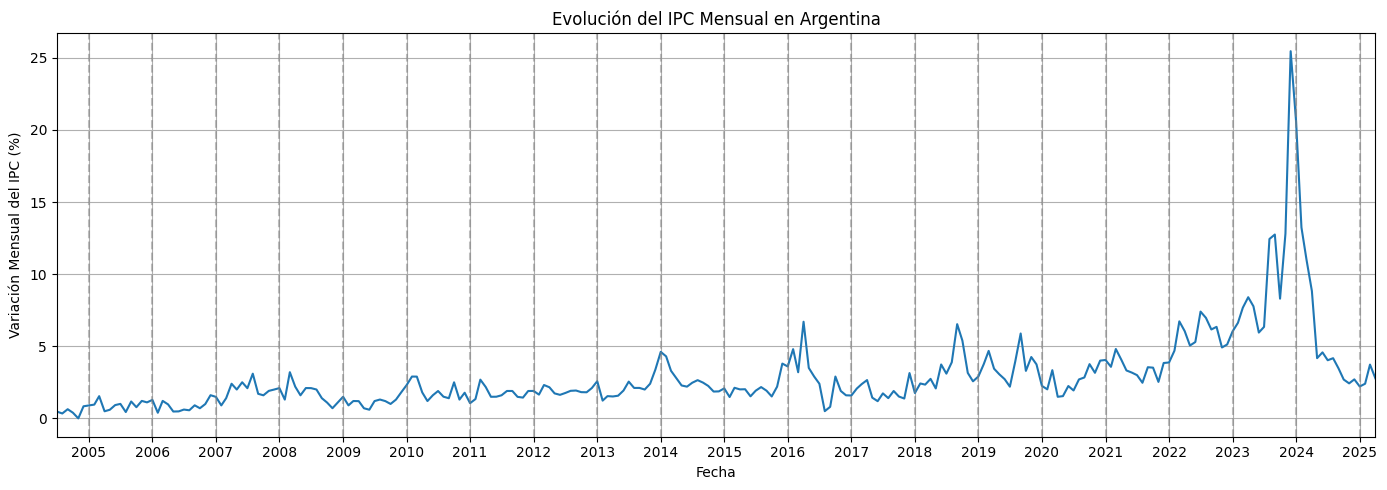

In [ ]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='fecha', y='ipc_var_mensual')

plt.title('Evolución del IPC Mensual en Argentina')
plt.xlabel('Fecha')
plt.ylabel('Variación Mensual del IPC (%)')
plt.grid(True)

ax = plt.gca()

start_date = pd.Timestamp('2004-07-01')
end_date = df['fecha'].max()

ax.set_xlim(start_date, end_date)

# Ticks anuales en cada 1 de enero
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Líneas verticales en cada año desde 2005 (el año siguiente a la fecha de inicio)
start_year = start_date.year + 1  # 2005
end_year = end_date.year

for year in range(start_year, end_year + 1):
    plt.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Construimos un histograma para ver como se distribuye el dato de IPC Mensual

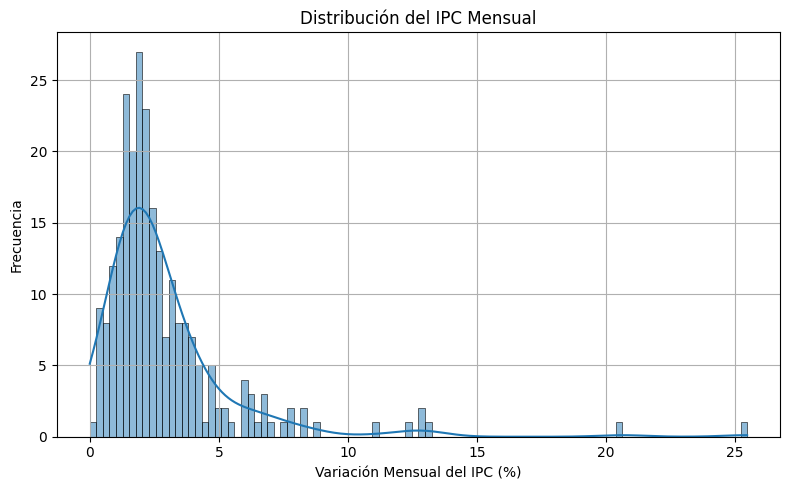

In [ ]:
# Histograma de distribución
plt.figure(figsize=(8, 5))
sns.histplot(df['ipc_var_mensual'], bins=100, kde=True)
plt.title('Distribución del IPC Mensual')
plt.xlabel('Variación Mensual del IPC (%)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.tight_layout()
plt.show()

Ajustamos el histograma a 10 para ver con más claridad la distribución, obviando los "outliers"

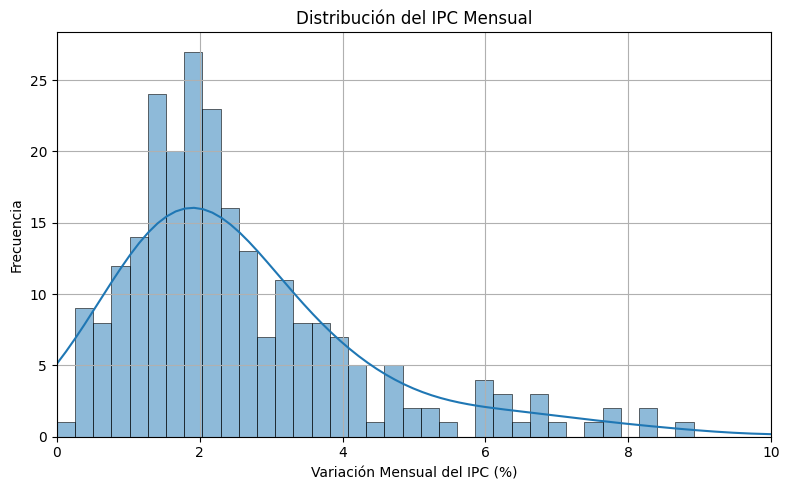

In [ ]:
# Histograma de distribución ajustado hasta 10
plt.figure(figsize=(8, 5))
sns.histplot(df['ipc_var_mensual'], bins=100, kde=True)
plt.title('Distribución del IPC Mensual')
plt.xlabel('Variación Mensual del IPC (%)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.xlim(0, 10)  # Limita el eje x de 0 a 10
plt.tight_layout()
plt.show()

Realizamos un boxplot con el fin de identificar algunos de los outliers

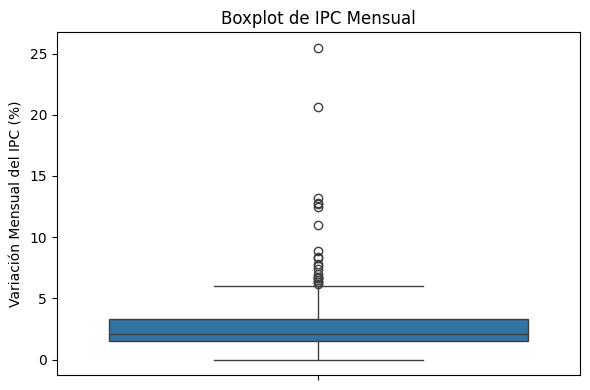

In [ ]:
# Boxplot para detección de outliers
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['ipc_var_mensual'])
plt.title('Boxplot de IPC Mensual')
plt.ylabel('Variación Mensual del IPC (%)')
plt.tight_layout()
plt.show()

Para verlo con mayor claridad, ajustamos el boxplot para datos entre 0 y 10

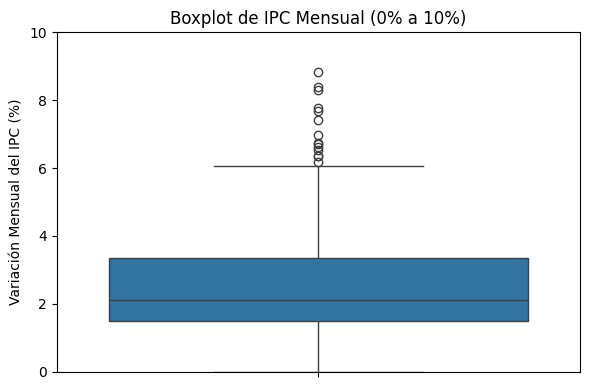

In [ ]:
# Boxplot ajustado con límite de y entre 0 y 10
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['ipc_var_mensual'])
plt.ylim(0, 10)
plt.title('Boxplot de IPC Mensual (0% a 10%)')
plt.ylabel('Variación Mensual del IPC (%)')
plt.tight_layout()
plt.show()

# Por qué es tan complejo tratar la inflación en Argentina


> En esta breve introducción, vamos a exponer las complejidades que el análisis de la inflación y su evolución tiene en la historia contemporánea Argentina.



In [ ]:
df = pd.read_csv('DATASET_V5.csv')
df

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre
0,2004-07-01,0.469016,0.76667,0.686892,0.604665,2.513810,-3.218377,2.050367,1.242962,3.025927,...,-0.095070,-0.077538,-0.032690,0.069494,-0.152372,0.260167,0.472477,1,False,3
1,2004-08-01,0.339511,0.54848,0.469016,0.686892,2.847619,0.733076,-3.218377,2.050367,0.025165,...,-0.220837,-0.096827,-0.078041,0.104483,-0.003841,0.177845,0.300105,1,False,3
2,2004-09-01,0.634428,0.58056,0.339511,0.469016,2.990455,0.267893,0.733076,-3.218377,0.341595,...,-0.085668,-0.021497,0.039039,0.020585,-0.061159,0.178686,0.298540,1,False,3
3,2004-10-01,0.392267,0.57500,0.634428,0.339511,3.026500,-3.456473,0.267893,0.733076,0.453109,...,-0.063035,-0.099907,-0.029683,0.159313,-0.044120,0.141137,0.270829,1,False,4
4,2004-11-01,0.000000,0.54688,0.392267,0.634428,3.023182,6.066549,-3.456473,0.267893,0.874522,...,0.012324,0.006280,0.033130,-0.087175,0.003676,0.246276,0.585881,1,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,2024-12-01,2.704104,2.90000,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,...,-0.011710,-0.078962,0.000321,0.003015,0.007559,0.747825,0.230161,1,False,4
245,2025-01-01,2.211048,2.50000,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,...,0.045999,0.070084,0.026025,0.078300,0.056845,0.736292,0.249945,2,False,1
246,2025-02-01,2.401627,2.10000,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,...,0.011197,0.045497,-0.002765,-0.054250,0.032164,0.442733,0.167024,2,False,1
247,2025-03-01,3.729335,2.10000,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,...,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029,0.540791,0.200734,2,False,1


### Análisis de ruptura estructural para la Argentina

Usamos un modelo de detección de quiebres estructurales (en este caso, con el algoritmo ruptures) para identificar los momentos en los que la dinámica de la inflación cambió significativamente.
Específicamente:

- Cargamos una serie de tiempo mensual de inflación para Argentina.

- Aplicamos un algoritmo (como PELT) que analiza la tendencia y la media de la serie.

- Este algoritmo detecta puntos en el tiempo donde la inflación mostró un cambio abrupto en su comportamiento, por ejemplo un salto a una nueva tendencia más acelerada, un cambio en el nivel medio, o una reducción momentánea.

Estos quiebres o puntos de cambio estructural son fechas donde el patrón inflacionario cambia, y el modelo los marca como significativos desde una perspectiva estadística.

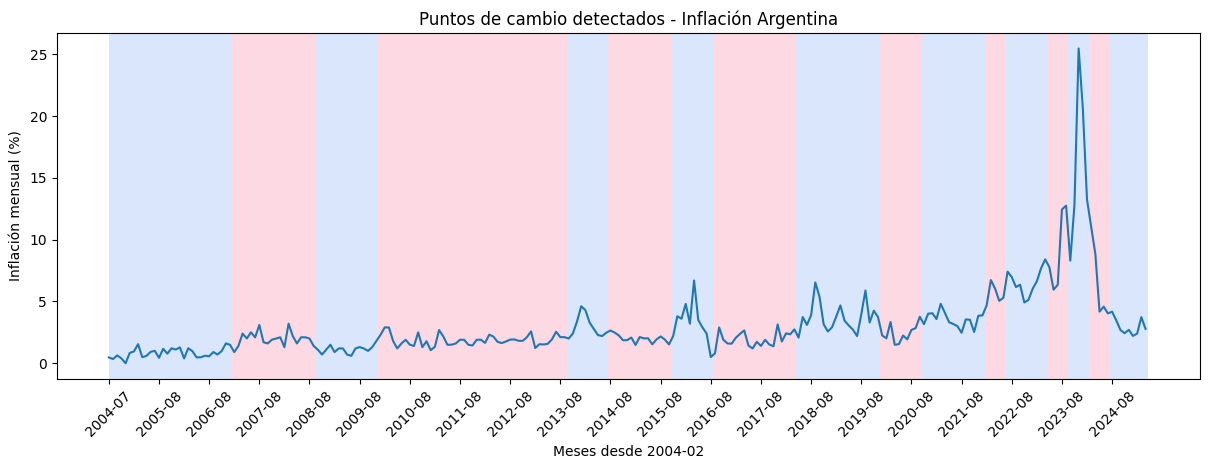

Fechas de cambio estructural detectadas:
0    2007-02-01
1    2008-10-01
2    2010-01-01
3    2013-10-01
4    2014-08-01
5    2015-11-01
6    2016-09-01
7    2018-05-01
8    2020-01-01
9    2020-11-01
10   2022-02-01
11   2022-07-01
12   2023-05-01
13   2023-10-01
14   2024-03-01
15   2024-08-01
Name: fecha, dtype: datetime64[ns]


In [ ]:
# Cargar el archivo
df = pd.read_csv("DATASET_V5.csv", parse_dates=["fecha"])
df = df.sort_values("fecha")

# Serie: inflación mensual para Argentina
serie = df["ipc_var_mensual"].values
fechas = df["fecha"]

# Detectar cambios con método Pelt y penalización
model = "l2"  # Euclidean distance (bueno para cambios en media)
ajuste = rpt.Pelt(model=model).fit(serie)
result = ajuste.predict(pen=3)  # Ajustá el valor de penalización, cuanto más alto, menos se penaliza

# Graficar
rpt.display(serie, result, figsize=(12, 4))
plt.title("Puntos de cambio detectados - Inflación Argentina") #CORRECCION
plt.xlabel("Meses desde 2004-02")
plt.xticks(ticks=range(0, len(fechas), 12), labels=fechas.dt.strftime("%Y-%m").iloc[::12], rotation=45)
plt.ylabel("Inflación mensual (%)")
plt.show()

# Ver resultados
# print("Puntos de cambio detectados:", result) #YO LO QUITARIA JOR
fechas_corte = df["fecha"].iloc[result[:-1]].reset_index(drop=True)

print("Fechas de cambio estructural detectadas:")
print(fechas_corte)

### **¿Por qué múltiples quiebres complican el análisis de la inflación en Argentina?**

Cada quiebre puede reflejar un cambio en el régimen macroeconómico: modificaciones de política monetaria, controles de precios, shocks externos o internos, crisis cambiarias, etc. En países estables, la inflación se suele analizar bajo un mismo modelo (por ejemplo, una curva de Phillips simple).
- En Argentina, hay que replantear el modelo cada pocos años, basandonos en las características estructurales en el momento específico en el que nos encontremos.

En este aspecto, siendo que intentamos desarrollar una modelización econométrica, dependiendo del momento del tiempo en el que nos paremos, la relación entre los features y la variable que pretendemos pronosticar puede variar considerablemente.


*   Ejemplo: no es lo mismo analizar inflación en 2010 (con tipo de cambio relativamente estable) que en 2018 o 2023 (con crisis de confianza o inflación "reprimida").



## Análisis de ruptura estructural para los Estados Unidos

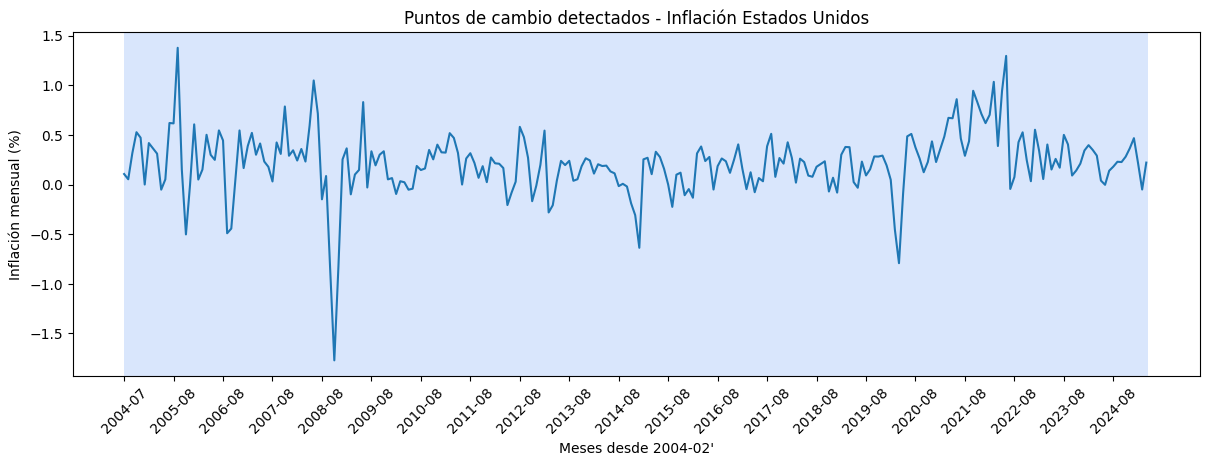

In [ ]:
# Cargar tu archivo
df = pd.read_csv("DATASET_V5.csv", parse_dates=["fecha"])
df = df.sort_values("fecha")

# Serie: inflación mensual para los Estados Unidos
serie = df["ipc_usa_varm"].values
fechas = df["fecha"]

# Detectar cambios con método Pelt y penalización
model = "l2"  # Euclidean distance (bueno para cambios en media)
algo = rpt.Pelt(model=model).fit(serie)
result = algo.predict(pen=3)  # Ajustá el valor de penalización

# Graficar
rpt.display(serie, result, figsize=(12, 4))
plt.title("Puntos de cambio detectados - Inflación Estados Unidos")
plt.xlabel("Meses desde 2004-02'")
plt.xticks(ticks=range(0, len(fechas), 12), labels=fechas.dt.strftime("%Y-%m").iloc[::12], rotation=45)
plt.ylabel("Inflación mensual (%)")
plt.show()

Cuando aplicás el algoritmo de detección de cambios a la serie de inflación mensual de EE. UU. (CPI - Consumer Price Index), el modelo generalmente no detecta quiebres significativos con respecto a la tendencia o la media, porque el patrón inflacionario es continuo, previsible y autocontenido (por lo menos, en los últimos años desde el 2004).

¿Por qué se da esto? Porque EE. UU. tiene:

- Un régimen monetario estable (la Fed es autónoma, creíble y coherente en su política).

- Anclaje de expectativas: la política de inflation targeting mantiene que la inflación esperada se mantenga cercana al objetivo del 2%.

- Instituciones sólidas y bajo uso de medidas discrecionales o heterodoxas (como congelamientos o cepos).

- Transparencia y coordinación de política fiscal y monetaria, con pocas sorpresas o shocks recurrentes.



## Análisis por períodos para Argentina

Utilizando las variables del modelo original, realizaremos un análisis de la importancia relativa de cada una a lo largo del tiempo, identificando cuáles predominan en distintos momentos.

Dado que la cantidad de cortes anteriormente fue bastante alta, reduciremos la penalización para hacer menos cortes en el tiempo (pasando el valor de penalización de 3 a 10).

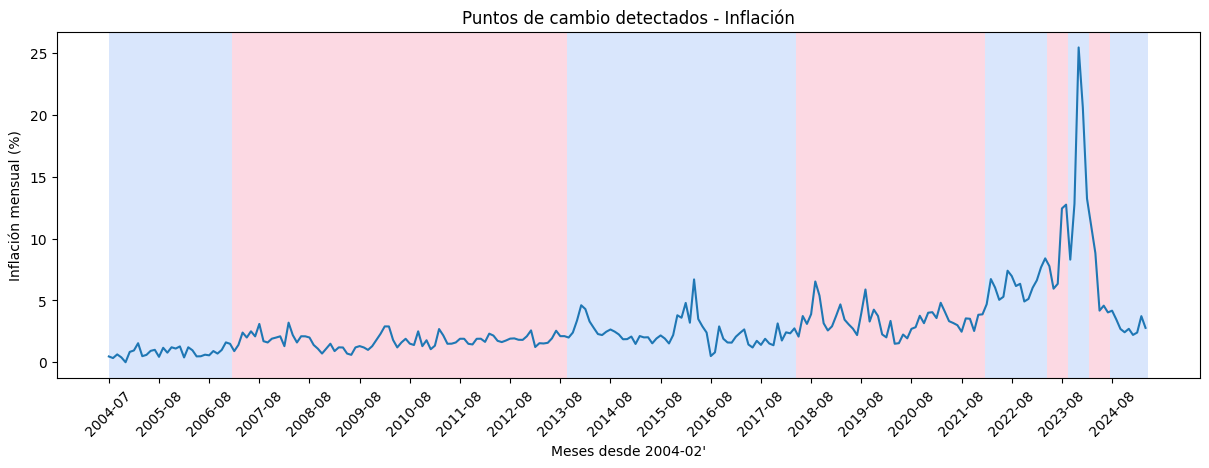

Puntos de cambio detectados: [30, 110, 165, 210, 225, 230, 235, 240, 249]


In [ ]:
# Cargar tu archivo
df = pd.read_csv("DATASET_V5.csv", parse_dates=["fecha"])
df = df.sort_values("fecha")

# Serie: inflación mensual para Estados Unidos
serie = df["ipc_var_mensual"].values
fechas = df["fecha"]

# Detectar cambios con método Pelt y penalización
model = "l2"  # Euclidean distance (bueno para cambios en media)
algo = rpt.Pelt(model=model).fit(serie)
result = algo.predict(pen=10)  # Ajustá el valor de penalización

# Graficar
rpt.display(serie, result, figsize=(12, 4))
plt.title("Puntos de cambio detectados - Inflación")
plt.xlabel("Meses desde 2004-02'")
plt.xticks(ticks=range(0, len(fechas), 12), labels=fechas.dt.strftime("%Y-%m").iloc[::12], rotation=45)
plt.ylabel("Inflación mensual (%)")
plt.show()

# Ver resultados
print("Puntos de cambio detectados:", result)

In [ ]:
# Obtener las fechas de los cortes (omitimos el último porque es el final de la serie)
fechas_corte = df["fecha"].iloc[result[:-1]].reset_index(drop=True)

print("Fechas de cambio estructural detectadas:")
print(fechas_corte)

Fechas de cambio estructural detectadas:
0   2007-02-01
1   2013-10-01
2   2018-05-01
3   2022-02-01
4   2023-05-01
5   2023-10-01
6   2024-03-01
7   2024-08-01
Name: fecha, dtype: datetime64[ns]


### Desde 2004-07 a 2007-02 (Régimen estable)

In [ ]:
df = pd.read_csv('DATASET_V5.csv')
# Asegúrate de que la columna 'fecha' sea de tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Define las fechas de inicio y fin
fecha_inicio = '2004-07-01'
fecha_fin = '2007-01-01'

# Filtra el DataFrame
df_filtrado_periodo = df[(df['fecha'] >= fecha_inicio) & (df['fecha'] <= fecha_fin)]
df = df_filtrado_periodo
df

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre
0,2004-07-01,0.469016,0.76667,0.686892,0.604665,2.513810,-3.218377,2.050367,1.242962,3.025927,...,-0.095070,-0.077538,-0.032690,0.069494,-0.152372,0.260167,0.472477,1,False,3
1,2004-08-01,0.339511,0.54848,0.469016,0.686892,2.847619,0.733076,-3.218377,2.050367,0.025165,...,-0.220837,-0.096827,-0.078041,0.104483,-0.003841,0.177845,0.300105,1,False,3
2,2004-09-01,0.634428,0.58056,0.339511,0.469016,2.990455,0.267893,0.733076,-3.218377,0.341595,...,-0.085668,-0.021497,0.039039,0.020585,-0.061159,0.178686,0.298540,1,False,3
3,2004-10-01,0.392267,0.57500,0.634428,0.339511,3.026500,-3.456473,0.267893,0.733076,0.453109,...,-0.063035,-0.099907,-0.029683,0.159313,-0.044120,0.141137,0.270829,1,False,4
4,2004-11-01,0.000000,0.54688,0.392267,0.634428,3.023182,6.066549,-3.456473,0.267893,0.874522,...,0.012324,0.006280,0.033130,-0.087175,0.003676,0.246276,0.585881,1,False,4
5,2004-12-01,0.837287,0.54138,0.000000,0.392267,2.969091,7.810991,6.066549,-3.456473,7.725800,...,0.014163,-0.020714,-0.028148,-0.108240,0.019732,0.283648,0.636814,1,False,4
6,2005-02-01,0.954589,0.46765,1.480764,0.837287,2.704000,0.609768,-5.934028,7.810991,0.110850,...,0.009835,0.019408,0.002859,0.021250,-0.017486,0.352614,0.669927,2,False,1
7,2005-03-01,1.539916,0.54667,0.954589,1.480764,2.786667,1.085293,0.609768,-5.934028,2.942463,...,0.180128,0.157559,0.055435,0.127161,0.059926,0.524201,0.721628,2,False,1
8,2005-04-01,0.492218,0.69677,1.539916,0.954589,3.097619,-0.713105,1.085293,0.609768,-0.257489,...,-0.018938,-0.028208,-0.076113,-0.019529,-0.035426,0.532344,0.757556,2,False,2
9,2005-05-01,0.595711,0.66111,0.492218,1.539916,3.570000,4.608286,-0.713105,1.085293,1.652046,...,0.020536,0.005600,-0.007578,-0.058722,-0.011465,0.514806,0.698876,2,False,2


In [ ]:
# Definir X (todas las columnas menos 'ipc_var_mensual' y 'fecha') y y (variable objetivo)
X = df.drop(columns=['fecha', 'ipc_var_mensual'])
y = df['ipc_var_mensual']

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=10)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X, y)

model = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor RMSE promedio:", -grid_search.best_score_)

Mejores parámetros: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Mejor RMSE promedio: 0.3893419212245137


/tmp/ipython-input-7-135782185.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


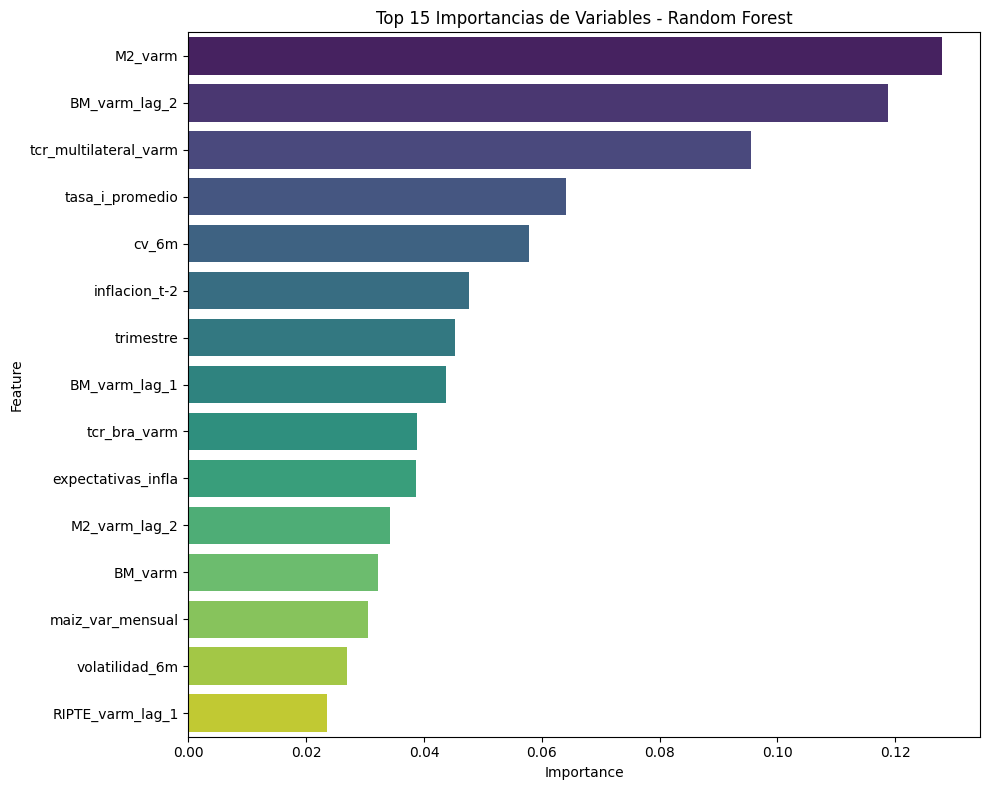

In [ ]:
# Entrenar el modelo en todos los datos para obtener importancias
model.fit(X, y)
importances = model.feature_importances_
features = X.columns

# Crear DataFrame con la importancia
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graficar importancias
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Importancias de Variables - Random Forest')
plt.tight_layout()
plt.show()

Vemos como en un contexto más estable, no hay una sola variable relevante, sino un conjunto balanceado de variables.

### Desde 2022-03 a 2024-03 (Régimen alta inflación)

In [ ]:
df = pd.read_csv('DATASET_V5.csv')
# Asegúrate de que la columna 'fecha' sea de tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Define las fechas de inicio y fin
fecha_inicio = '2022-03-01'
fecha_fin = '2024-03-01'

# Filtra el DataFrame
df_filtrado_periodo = df[(df['fecha'] >= fecha_inicio) & (df['fecha'] <= fecha_fin)]
df = df_filtrado_periodo
df

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre
211,2022-03-01,6.728798,4.3,4.694366,3.875682,40.200000,-4.308712,1.127912,-0.629140,-0.315802,...,0.057402,0.132025,0.115572,0.183293,0.147808,1.423527,0.339143,3,False,1
212,2022-04-01,6.047319,4.4,6.728798,4.694366,42.938947,-0.121009,-4.308712,1.127912,1.860479,...,0.001523,0.043872,0.047365,-0.059169,0.037438,1.550651,0.335692,3,False,2
213,2022-05-01,5.050228,4.4,6.047319,6.728798,45.182000,7.359211,-0.121009,-4.308712,-47.708246,...,-0.001643,0.053309,0.093909,0.075771,-0.010324,1.164646,0.231108,3,False,2
214,2022-06-01,5.295221,5.1,5.050228,6.047319,47.785000,5.682694,7.359211,-0.121009,5.177584,...,0.006604,-0.086261,-0.104702,0.045238,-0.026651,1.005572,0.190379,3,False,2
215,2022-07-01,7.406197,4.8,5.295221,5.050228,50.875238,8.414984,5.682694,7.359211,9.467328,...,-0.080806,-0.183920,-0.190310,-0.111251,-0.068615,1.050085,0.178879,3,False,3
216,2022-08-01,6.970336,5.9,7.406197,5.295221,60.912273,-2.909776,8.414984,5.682694,0.941870,...,0.010197,0.107579,0.003235,-0.080707,-0.059969,0.946262,0.151410,3,False,3
217,2022-09-01,6.165520,6.2,6.970336,7.406197,66.962857,-2.202972,-2.909776,8.414984,-1.278332,...,-0.068083,-0.006210,0.072149,-0.099182,0.063332,0.916701,0.148917,3,False,3
218,2022-10-01,6.347350,6.3,6.165520,6.970336,69.685789,4.875277,-2.202972,-2.909776,5.560651,...,-0.055823,0.025660,0.021341,0.034202,0.099208,0.917783,0.147891,3,False,4
219,2022-11-01,4.916147,6.2,6.347350,6.165520,69.560476,4.858395,4.875277,-2.202972,4.580051,...,0.043748,0.069818,-0.026527,-0.036779,-0.065852,0.952522,0.154043,3,False,4
220,2022-12-01,5.124608,6.2,4.916147,6.347350,70.061000,15.440222,4.858395,4.875277,9.860989,...,0.022810,-0.131149,-0.060044,-0.089140,-0.058250,0.986290,0.160241,3,False,4


In [ ]:
# Definir X (todas las columnas menos 'ipc_var_mensual' y 'fecha') y y (variable objetivo)
X = df.drop(columns=['fecha', 'ipc_var_mensual'])
y = df['ipc_var_mensual']

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=10)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X, y)

model = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor RMSE promedio:", -grid_search.best_score_)

Mejores parámetros: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Mejor RMSE promedio: 3.0471594932890778


/tmp/ipython-input-24-135782185.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


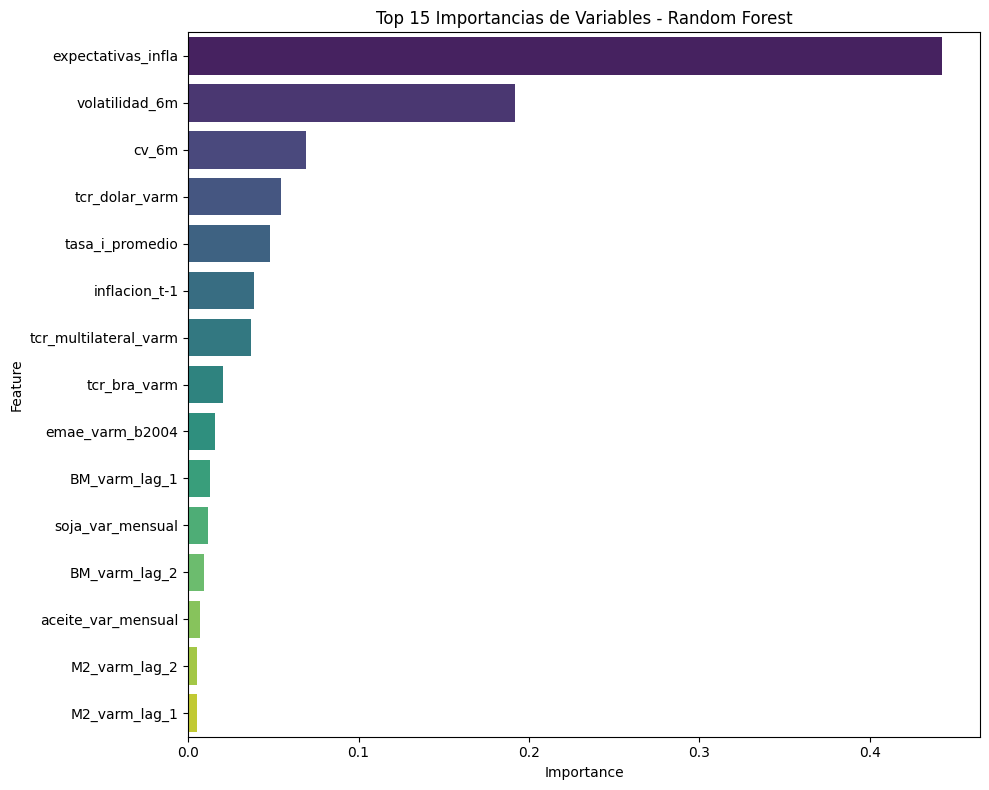

In [ ]:
# Entrenar el modelo en todos los datos para obtener importancias
model.fit(X, y)
importances = model.feature_importances_
features = X.columns

# Crear DataFrame con la importancia
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graficar importancias
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Importancias de Variables - Random Forest')
plt.tight_layout()
plt.show()

Por otro lado, bajo el régimen de alta inflación de los últimos años, se observa un cambio significativo en los determinantes del proceso inflacionario.
- La inflación se vuelve altamente dependiente de las expectativas: cuando el régimen es inestable, los agentes económicos reaccionan más a lo que anticipan que a lo que ocurre en el presente.

- Se pierde la conexión directa con fundamentos tradicionales como M2 o TCR.

- La inflación pasada o los agregados monetarios tienen un rol marginal.

- El proceso inflacionario se vuelve más autorreferencial y subjetivo: expectativas alimentan inflación futura, independientemente de fundamentos.



### Desde 2018-05 a 2022-02 (Régimen moderado)

In [ ]:
df = pd.read_csv('DATASET_V5.csv')
# Asegúrate de que la columna 'fecha' sea de tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Define las fechas de inicio y fin
fecha_inicio = '2018-05-01'
fecha_fin = '2022-02-01'

# Filtra el DataFrame
df_filtrado_periodo = df[(df['fecha'] >= fecha_inicio) & (df['fecha'] <= fecha_fin)]
df = df_filtrado_periodo
df

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre
165,2018-05-01,2.075375,1.7,2.739032,2.341063,25.144286,2.112054,0.390367,-0.742433,-0.071151,...,-0.016839,-0.011105,0.068343,0.054059,0.020376,0.487190,0.201960,3,False,2
166,2018-06-01,3.736676,2.5,2.075375,2.739032,27.397500,2.270139,2.112054,0.390367,1.948672,...,-0.093079,-0.038048,0.001948,-0.028935,-0.078351,0.685473,0.272942,3,False,2
167,2018-07-01,3.101613,2.6,3.736676,2.075375,31.453810,2.220802,2.270139,2.112054,4.509455,...,-0.080586,-0.050620,0.019302,0.047120,-0.051992,0.604632,0.221035,3,False,3
168,2018-08-01,3.889439,2.4,3.101613,3.736676,32.007727,13.260762,2.220802,2.270139,-0.604953,...,0.013107,-0.001770,0.073605,-0.044280,0.038121,0.734722,0.246507,3,False,3
169,2018-09-01,6.534286,4.0,3.889439,3.101613,38.124000,3.424797,13.260762,2.220802,0.605531,...,-0.032293,-0.010978,-0.095354,0.033317,-0.046623,1.548470,0.420848,3,False,3
170,2018-10-01,5.391607,4.1,6.534286,3.889439,46.114545,-7.568077,3.424797,13.260762,-1.397057,...,0.030738,0.034557,-0.014036,0.008015,0.034984,1.603961,0.389169,3,False,4
171,2018-11-01,3.153365,3.3,5.391607,6.534286,47.597895,7.255675,-7.568077,3.424797,-1.135123,...,0.020356,-0.042397,-0.036661,-0.205855,0.003197,1.372620,0.319128,3,False,4
172,2018-12-01,2.569823,2.8,3.153365,5.391607,45.610000,13.728891,7.255675,-7.568077,11.970016,...,0.025445,0.018672,0.038465,-0.129371,0.041097,1.540935,0.375226,3,False,4
173,2019-01-01,2.906241,2.6,2.569823,3.153365,43.973636,-3.986722,13.728891,7.255675,0.050286,...,0.009971,0.024194,0.001640,0.047187,-0.003843,1.568243,0.384927,4,True,1
174,2019-02-01,3.765622,2.6,2.906241,2.569823,36.928000,3.716426,-3.986722,13.728891,-1.457707,...,0.002175,0.046220,-0.057869,0.073566,0.016842,1.571970,0.387806,4,True,1


In [ ]:
# Definir X (todas las columnas menos 'ipc_var_mensual' y 'fecha') y y (variable objetivo)
X = df.drop(columns=['fecha', 'ipc_var_mensual'])
y = df['ipc_var_mensual']

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=10)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X, y)

model = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor RMSE promedio:", -grid_search.best_score_)

Mejores parámetros: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Mejor RMSE promedio: 0.8938002226668365


/tmp/ipython-input-27-135782185.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


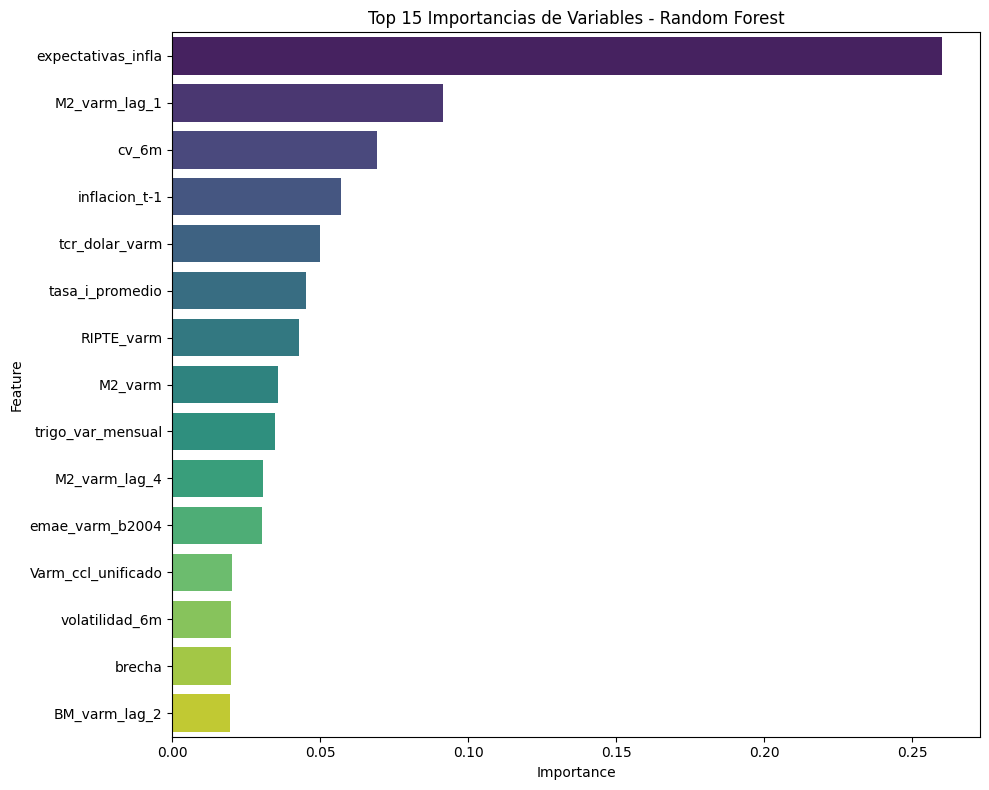

In [ ]:
# Entrenar el modelo en todos los datos para obtener importancias
model.fit(X, y)
importances = model.feature_importances_
features = X.columns

# Crear DataFrame con la importancia
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graficar importancias
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Importancias de Variables - Random Forest')
plt.tight_layout()
plt.show()

### Comparación y conclusión

En contextos de **inflación estable**, como se observa en muchos países desarrollados o en ciertos períodos puntuales de la historia económica argentina, los modelos econométricos muestran una mayor capacidad predictiva basada en **fundamentos clásicos**. Variables como los agregados monetarios, el tipo de cambio real, la tasa de interés y la inflación rezagada tienden a conservar una relación estructural coherente con la evolución de los precios.

Esta configuración permite aplicar marcos teóricos como la **curva de Phillips** con cierto grado de robustez empírica (Galí y Gertler, 1999), ya que los cambios en la inflación pueden atribuirse, en buena parte, a **shocks reales** y a la respuesta de la **política monetaria**, dentro de **regímenes institucionales previsibles**.

En contraste, los **regímenes de alta inflación** como el argentino en los últimos años, revelan una **dinámica significativamente distinta**. La variable de mayor importancia en el **pronóstico de la inflación pasa a ser la expectativa de la misma**, superando ampliamente al resto de los determinantes tradicionales.

Este fenómeno puede interpretarse como una **evidencia de desanclaje** donde la curva de Phillips se torna predominantemente prospectiva y las decisiones económicas responden más a percepciones sobre el futuro que a fundamentos actuales.

En estos escenarios, la inflación deja de ser el resultado de desequilibrios monetarios o reales, y pasa a estar gobernada por **dinámicas autorreferenciales**, donde las expectativas alimentan nuevas rondas de inflación, generando una espiral difícil de controlar (Cagan, 1956; Heymann y Leijonhufvud, 1995).

Esta transformación complejiza la tarea de los modelos econométricos, ya que requiere incorporar no solo variables observables, sino también factores subjetivos e inestables, que desafían tanto la predicción como el diseño de políticas efectivas.

## Apéndice: Intervención INDEC

Entre 2007 y 2015, el Instituto Nacional de Estadística y Censos (INDEC) fue objeto de una intervención política que alteró profundamente la veracidad de sus estadísticas, particularmente las relacionadas con la inflación. Durante ese período, el índice de precios al consumidor dejó de reflejar con precisión la verdadera evolución de los precios en la economía.

Cualquier **modelo econométrico** que utilice los datos oficiales de inflación en ese período como variable dependiente estará **entrenando sobre una realidad distorsionada**. Esto puede llevar a conclusiones erróneas sobre relaciones económicas fundamentales (por ejemplo, con el dinero, el tipo de cambio o las expectativas).

Para sortear esta limitación, se recurrió al uso de diversas alternativas de índices de precios, como el **IPC San Luis** o el **IPC Congreso**, con el objetivo de contar con una estimación más realista de la inflación durante esos años.


Sin embargo, una de las variables más relevantes en nuestro análisis, la expectativa de inflación, resulta especialmente difícil de obtener con precisión para este período, lo que limita la posibilidad de incorporarla adecuadamente al modelo para esos años.

### Tratamiento de las expectativas de inflación

In [ ]:
df = pd.read_csv("/content/DATASET_V4.csv") # Para este caso vamos a utilizar una comparación viendo
df

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,Varm_ccl_implicito,tcr_multilateral_varm,tcr_bra_varm,tcr_dolar_varm,ipc_usa_varm,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual
0,2004-02,0.087719,0.45517,0.425782,0.205973,2.310500,-0.217049,1.299821,5.059221,2.666012,...,0.446602,0.5,-1.1,1.2,0.214707,0.052021,0.095054,-0.037720,0.016858,0.057523
1,2004-03,0.598890,0.49643,0.087719,0.425782,2.384348,-2.684893,-0.217049,1.299821,1.506627,...,-6.522468,-2.0,-0.1,-1.3,0.214247,0.139388,0.047685,0.005749,0.058720,0.044966
2,2004-04,0.856687,0.51212,0.598890,0.087719,2.139474,3.138080,-2.684893,-0.217049,2.943459,...,5.027076,-3.2,-2.5,-2.8,0.160342,0.007844,-0.025801,0.024666,-0.001136,0.038761
3,2004-05,0.604665,0.52759,0.856687,0.598890,2.454000,1.242962,3.138080,-2.684893,-0.033009,...,7.904991,0.2,-3.5,2.6,0.426894,-0.043008,-0.055279,-0.019721,0.096783,-0.031132
4,2004-06,0.686892,0.59375,0.604665,0.856687,2.489524,2.050367,1.242962,3.138080,1.583698,...,2.797813,1.2,0.2,1.1,0.371945,-0.079458,-0.081398,-0.044159,-0.055409,-0.046459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-12,2.704104,2.90000,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,...,7.266766,-2.4,-4.7,-0.2,0.364672,-0.011710,-0.078962,0.000321,0.003015,0.007559
250,2025-01,2.211048,2.50000,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,...,1.280873,-0.1,1.1,0.0,0.466935,0.045999,0.070084,0.026025,0.078300,0.056845
251,2025-02,2.401627,2.10000,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,...,0.335913,1.7,4.6,-0.5,0.215929,0.011197,0.045497,-0.002765,-0.054250,0.032164
252,2025-03,3.729335,2.10000,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,...,8.535103,-0.7,-1.1,-1.9,-0.050035,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029


Elaboramos un gráfico utilizando los datos de expectativas disponibles, teniendo en cuenta que entre octubre de 2012 y mayo de 2016 no se registran datos del REM del BCRA.

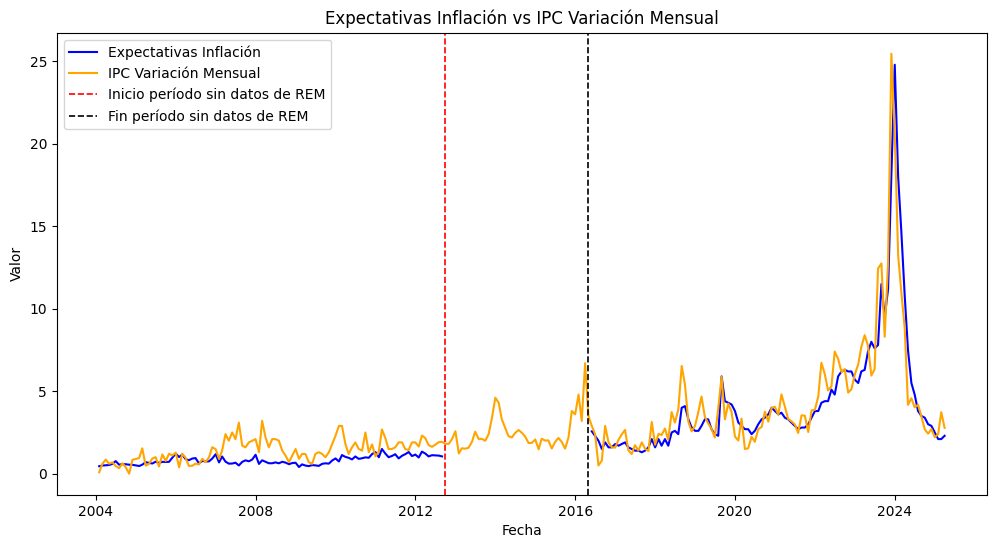

In [ ]:
# Asegurarse de que la fecha es datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Eliminar expectativas en el rango deseado
fecha_inicio = pd.to_datetime('2012-10-01')
fecha_fin = pd.to_datetime('2016-05-01')
mascara_rango = (df['fecha'] >= fecha_inicio) & (df['fecha'] <= fecha_fin)
df.loc[mascara_rango, 'expectativas_infla'] = None

# Gráfico
plt.figure(figsize=(12, 6))

# Graficar usando matplotlib para controlar cómo se manejan los NaN
plt.plot(df['fecha'], df['expectativas_infla'], label='Expectativas Inflación', color='blue')
plt.plot(df['fecha'], df['ipc_var_mensual'], label='IPC Variación Mensual', color='orange')

# Agregar líneas verticales para marcar el rango con valores None
plt.axvline(fecha_inicio, color='red', linestyle='--', linewidth=1.2, label='Inicio período sin datos de REM')
plt.axvline(fecha_fin, color='black', linestyle='--', linewidth=1.2, label='Fin período sin datos de REM')

plt.title('Expectativas Inflación vs IPC Variación Mensual')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.show()

### Consideraciones para los datos disponibles del BCRA (2007-03 a 2012-09)

Desde Febrero de 2007 a Septiembre de 2012 hubo una subestimación sistemática por parte de la estadística del BCRA con respecto a la inflación. Directamente para el período entre Octubre de 2012 y Mayo de 2016 no hay información directa del BCRA.
Con el fin de que esto no altere los resultados de nuestro modelo, elegimos que para el período que va desde 2007-02 a 2016-05 el valor para las expectativas fuera de -99. Esto para que el modelo identificar claramente que se trata de un valor artificial o faltante, evitando interpretarlo como un dato real y permitiendo su tratamiento diferenciado durante el entrenamiento o la predicción.

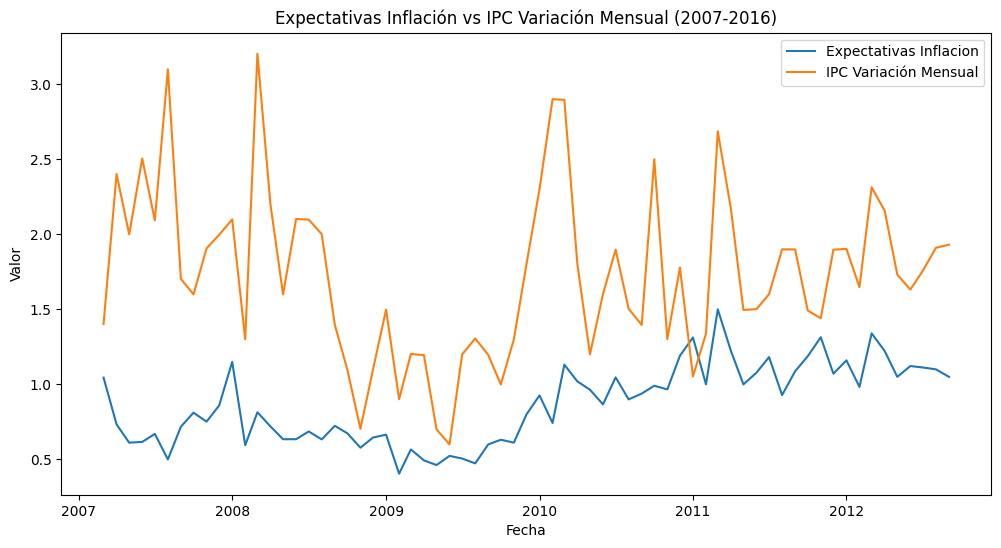

In [ ]:
# Filtrar el DataFrame para el rango de fechas
df_filtrado = df[(df['fecha'] >= '2007-03-01') & (df['fecha'] <= '2012-09-01')]

# Graficar usando el DataFrame filtrado
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtrado, x='fecha', y='expectativas_infla', label='Expectativas Inflacion')
sns.lineplot(data=df_filtrado, x='fecha', y='ipc_var_mensual', label='IPC Variación Mensual')
plt.title('Expectativas Inflación vs IPC Variación Mensual (2007-2016)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.show()

# Modelo Random Forest

## Nowcasting de inflación

La demanda de información económica de **alta frecuencia** impulsó el desarrollo del concepto de **Nowcasting** entre diversos investigadores. De acuerdo con *Bañbura et al.* (2013), este enfoque se concentra en pronosticar el **momento actual**, el **futuro inmediato** o el **pasado reciente**. El término combina las palabras "**now**" (ahora) y "**forecasting**" (pronóstico), reflejando esta orientación temporal específica. La efectividad de esta metodología se fundamenta en evidencia empírica que demuestra cómo la **incorporación progresiva de nueva información** mejora la **precisión de las predicciones**, al ser integrada y analizada mediante modelos actualizados (*Giannone et al.*, 2008; *Knotek y Zaman*, 2017; *Banbura et al.*, 2013).

El **principio fundamental** del Nowcasting consiste en generar **estimaciones anticipadas** de una variable específica empleando datos que están **disponibles antes** que los valores de la variable que se desea pronosticar (*Banbura et al.*, 2013). La **meta primordial** es **maximizar el aprovechamiento** de la información accesible en **tiempo real** para realizar predicciones, priorizando la identificación de **correlaciones** por encima del establecimiento de vínculos causales (*Espinoza*, 2022).


Por lo general, la implementación de estas metodologías se lleva a cabo mediante modelos econométricos diseñados para predecir indicadores de inflación o Producto Bruto Interno utilizando variables que se encuentran disponibles con mayor anticipación. Dentro de los estudios orientados a pronosticar la inflación mediante información previa, destacan investigaciones como la desarrollada por Modugno (2013). Este investigador incorpora información de alta frecuencia sobre precios energéticos, commodities y variables financieras con periodicidad diaria y semanal para realizar pronósticos inflacionarios en la eurozona y Estados Unidos, empleando modelos de componentes principales y Vectores Autorregresivos (VAR).

Diferenciándose de gran parte de los estudios de Nowcasting, ciertos investigadores optan por seleccionar meticulosamente un conjunto reducido de series temporales con distintas frecuencias para realizar predicciones inmediatas, prescindiendo del uso de modelos de componentes principales (Knotek y Zaman, 2017). Estos académicos desarrollan un modelo innovador y simplificado para pronosticar tanto la inflación general como el índice de precios del gasto de consumo personal (PCE) estadounidense, basándose en un número limitado de variables de precios y utilizando modelos de mínimos cuadrados no lineales junto con modelos de factores dinámicos. Como punto de referencia comparativa, emplean modelos de menor complejidad para evaluar el rendimiento, incluyendo un modelo Random Walk.

In [ ]:
df = pd.read_csv("/content/DATASET_V5.csv")
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')

In [ ]:
# Definimos X (todas las columnas menos 'ipc_var_mensual') #cambio -> puse fecha como index antes de separar x e y
X = df.drop(columns=[ 'ipc_var_mensual'])
y = df['ipc_var_mensual']

### Decisión de hiperparámetros y número de splits

Para 5 splits

In [ ]:
# Para ver Hiperp. óptimos
inicio = time.time()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 3],
    'criterion': ['absolute_error']
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X, y)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor MAE promedio:", -grid_search.best_score_)

fin = time.time()

print(" ###  \nTiempo de ejecución:", fin - inicio, "segundos")

Mejores parámetros: {'criterion': 'absolute_error', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejor MAE promedio: 1.1851676890754332
 ###  
Tiempo de ejecución: 120.37052130699158 segundos


Para 10 splits

In [ ]:
# Para ver Hiperp. óptimos
inicio = time.time()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 3],
    'criterion': ['absolute_error']
}

tscv = TimeSeriesSplit(n_splits=10)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X, y)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor MAE promedio:", -grid_search.best_score_)

fin = time.time()

print(" ###  \nTiempo de ejecución:", fin - inicio, "segundos")

Mejores parámetros: {'criterion': 'absolute_error', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejor MAE promedio: 1.0742904929512693
 ###  
Tiempo de ejecución: 244.13648796081543 segundos


Para 20 splits

In [ ]:
# Para ver Hiperp. óptimos
inicio = time.time()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 3],
    'criterion': ['absolute_error']
}

tscv = TimeSeriesSplit(n_splits=20)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X, y)

model = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor MAE promedio:", -grid_search.best_score_)

fin = time.time()

print(" ###  \nTiempo de ejecución:", fin - inicio, "segundos")

Mejores parámetros: {'criterion': 'absolute_error', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejor MAE promedio: 0.9760427574505608
 ###  
Tiempo de ejecución: 486.4506199359894 segundos


In [ ]:
model

RandomForestRegressor(criterion='absolute_error', max_depth=15,
                      min_samples_leaf=2, random_state=42)

Encontramos que el número de n_splits que mejor MAE promedio arroja es de 20. A su vez, los hiperparámetros que optimizan el modelo son:
- n_estimators=100
- max_depth=15
- min_samples_split=2
- min_samples_leaf=2
- criterion='absolute_error'

Utilizamos los parámetros del modelo de forma manual para no tener que correr el GridSearch

In [ ]:
modelo_nowcasting_manual = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=2,
    criterion='absolute_error',
    random_state=42,
    n_jobs=-1
)

model = modelo_nowcasting_manual

Corremos el modelo, y vemos sus features más importantes

/tmp/ipython-input-20-1905999860.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


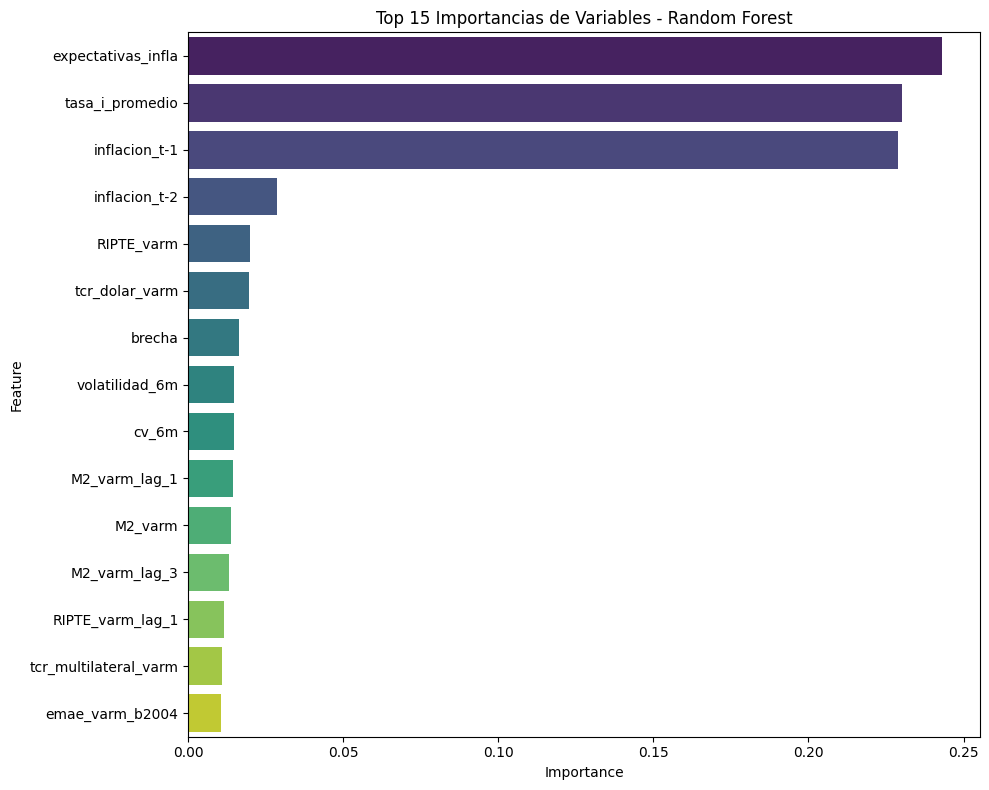


--- Tabla de Importancia de Variables (de mayor a menor) ---
                  Feature  Importance
0      expectativas_infla    0.243160
3         tasa_i_promedio    0.230095
1           inflacion_t-1    0.228952
2           inflacion_t-2    0.028770
13             RIPTE_varm    0.019753
20         tcr_dolar_varm    0.019660
15                 brecha    0.016502
27         volatilidad_6m    0.014704
28                  cv_6m    0.014676
8           M2_varm_lag_1    0.014334
7                 M2_varm    0.013858
10          M2_varm_lag_3    0.013146
14       RIPTE_varm_lag_1    0.011535
18  tcr_multilateral_varm    0.010989
12        emae_varm_b2004    0.010576
6           BM_varm_lag_2    0.010365
4                 BM_varm    0.009794
24      trigo_var_mensual    0.009074
25   petroleo_var_mensual    0.008054
23     aceite_var_mensual    0.007859
11          M2_varm_lag_4    0.007580
5           BM_varm_lag_1    0.007337
17     Varm_ccl_implicito    0.007306
22       soja_var_mensual 

In [ ]:
# Entrenar el modelo en todos los datos para obtener importancias
model.fit(X, y)
importances = model.feature_importances_
features = X.columns

# Crear DataFrame con la importancia
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graficar importancias
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Importancias de Variables - Random Forest')
plt.tight_layout()
plt.show()

# Lista de Importancia de las Variables
print("\n--- Tabla de Importancia de Variables (de mayor a menor) ---")
print(feature_importance_df)

### Predicción para el modelo de Nowcasting:

In [ ]:
#MAE del modelo:
y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)

print(f"MAE: {mae:.4f}")

MAE: 0.3418


In [ ]:
#Para ver prediccion sobre Abril 2025
df_resultados = pd.DataFrame({
    'real': y,
    'predicho': y_pred
}, index=y.index)

mes_objetivo = '2025-04-01'
df_mes = df_resultados.loc[mes_objetivo]
print(df_mes)

real        2.780836
predicho    3.004607
Name: 2025-04-01 00:00:00, dtype: float64


Graficamos finalmente las predicciones realizadas utilizando el modelo, asi como el dato real de inflación para cada uno de los meses analizados.

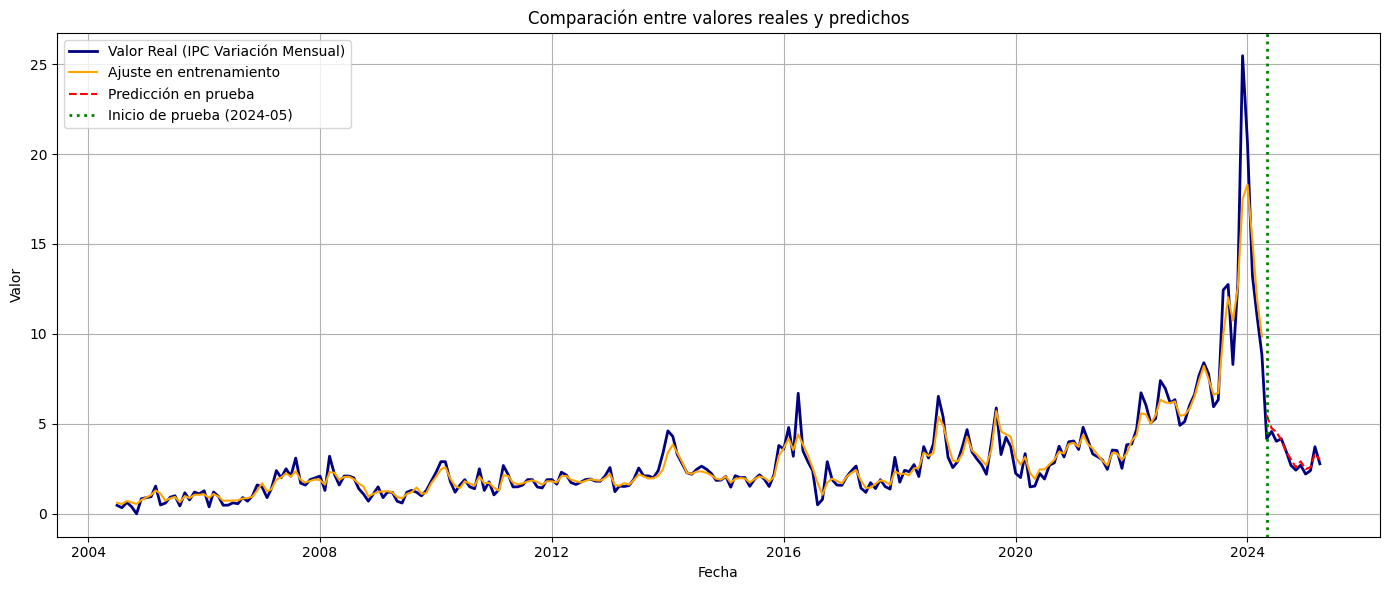

In [ ]:
mes_objetivo = '2024-05-01'
fecha_objetivo = pd.to_datetime(mes_objetivo)

plt.figure(figsize=(14, 6))

# Línea real completa
plt.plot(y.index, y, label='Valor Real (IPC Variación Mensual)', color='navy', linewidth=2)

# Use the modelo_nowcasting_manual model for prediction
y_pred = model.predict(X)

# Predicho antes del mes objetivo
plt.plot(
    X.index[X.index < fecha_objetivo],
    y_pred[X.index < fecha_objetivo],
    label='Ajuste en entrenamiento',
    color='orange',
)

# Predicho desde el mes objetivo en adelante
plt.plot(
    X.index[X.index >= fecha_objetivo],
    y_pred[X.index >= fecha_objetivo],
    label='Predicción en prueba',
    color='red',
    linestyle='--'
)

# Línea vertical del inicio de prueba
plt.axvline(fecha_objetivo, color='green', linestyle=':', linewidth=2, label='Inicio de prueba (2024-05)')

# Estética
plt.title('Comparación entre valores reales y predichos')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Nowcasting simplificado

In [ ]:
df = pd.read_csv("/content/DATASET_V5.csv")
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')

Vemos a ver si la performance mejora eliminando features "irrelevantes". Arbitrariamente elegimos sacar aquellas < 0,01 en feature importance

In [ ]:
umbral = 0.01

features_importantes = feature_importance_df[feature_importance_df['Importance'] > umbral]['Feature'].tolist()
df = df[["ipc_var_mensual"]+ features_importantes] #mantener ipc y agregar features que pasaron el filtro
df.columns

Index(['ipc_var_mensual', 'M2_varm', 'BM_varm_lag_2', 'tcr_multilateral_varm',
       'tasa_i_promedio', 'cv_6m', 'inflacion_t-2', 'trimestre',
       'BM_varm_lag_1', 'tcr_bra_varm', 'expectativas_infla', 'M2_varm_lag_2',
       'BM_varm', 'maiz_var_mensual', 'volatilidad_6m', 'RIPTE_varm_lag_1',
       'año_mandato', 'M2_varm_lag_4', 'brecha', 'aceite_var_mensual',
       'M2_varm_lag_3', 'inflacion_t-1', 'M2_varm_lag_1',
       'petroleo_var_mensual'],
      dtype='object')

In [ ]:
#Ahora reentrenamos el modelo (Procedimiento analogo al anterior)
# Definimos X (todas las columnas menos 'ipc_var_mensual')

X = df.drop(columns=[ 'ipc_var_mensual'])
y = df['ipc_var_mensual']

In [ ]:
# Para ver Hiperp. óptimos
# Usamos time para ver cuanto tardo en correr el codigo #cambio
inicio = time.time()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 3],
    'criterion': ['absolute_error']
}

tscv = TimeSeriesSplit(n_splits=20)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X, y)

model = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor MAE promedio:", -grid_search.best_score_)

fin = time.time()

print(" ###  \nTiempo de ejecución:", fin - inicio, "segundos")

Mejores parámetros: {'criterion': 'absolute_error', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejor MAE promedio: 0.9766922904941774
 ###  
Tiempo de ejecución: 380.18467807769775 segundos


In [ ]:
# Guardamos el modelo y sus hiperparámetros de forma manual (para no tener que correr el GridSearch)
modelo_nowcasting_simplificado = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    criterion='absolute_error',
    random_state=42,
    n_jobs=-1
)

model = modelo_nowcasting_simplificado

print("¡Modelo final manual entrenado!")

¡Modelo final manual entrenado!


/tmp/ipython-input-28-1905999860.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


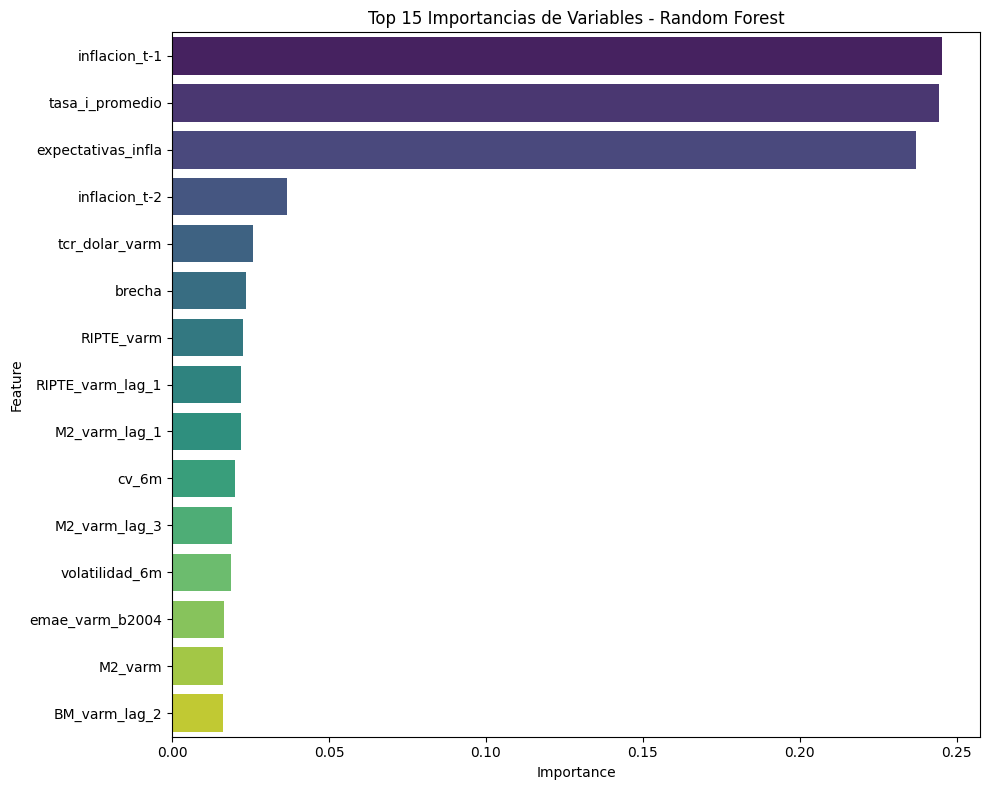


--- Tabla de Importancia de Variables (de mayor a menor) ---
                  Feature  Importance
2           inflacion_t-1    0.245177
1         tasa_i_promedio    0.244365
0      expectativas_infla    0.236905
3           inflacion_t-2    0.036444
5          tcr_dolar_varm    0.025909
6                  brecha    0.023688
4              RIPTE_varm    0.022633
12       RIPTE_varm_lag_1    0.022028
9           M2_varm_lag_1    0.021942
8                   cv_6m    0.020178
11          M2_varm_lag_3    0.019106
7          volatilidad_6m    0.018847
14        emae_varm_b2004    0.016547
10                M2_varm    0.016253
15          BM_varm_lag_2    0.016238
13  tcr_multilateral_varm    0.013739


In [ ]:
# Entrenar el modelo en todos los datos para obtener importancias
model.fit(X, y)
importances = model.feature_importances_
features = X.columns

# Crear DataFrame con la importancia
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graficar importancias
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Importancias de Variables - Random Forest')
plt.tight_layout()
plt.show()

# Lista de Importancia de las Variables
print("\n--- Tabla de Importancia de Variables (de mayor a menor) ---")
print(feature_importance_df)

In [ ]:
#MSE del modelo:
y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)

print(f"MAE: {mae:.4f}")

MAE: 0.3503


In [ ]:
#Para ver prediccion sobre Abril 2025
df_resultados = pd.DataFrame({
    'real': y,
    'predicho': y_pred
}, index=y.index)

mes_objetivo = '2025-04-01'
df_mes = df_resultados.loc[mes_objetivo]
print(df_mes)

real        2.780836
predicho    3.112818
Name: 2025-04-01 00:00:00, dtype: float64


- MAE Modelo General: 0.3418
- MAE Modelo Simplificado: 0.3503

Comparando el modelo general con el modelo simplificado, vemos que el MAE es mayor en el caso del segundo. Esto indica que, al reducir la complejidad del modelo (ya sea por eliminar variables, acotar la grilla de hiperparámetros o restringir su capacidad de aprendizaje), se pierde algo de capacidad predictiva, reflejado en un aumento del error medio absoluto.

### Conclusión Modelo Nowcasting
En este trabajo desarrollamos un modelo de predicción de la inflación mensual (IPC) utilizando datos disponibles hasta abril de 2025. Si bien nuestro objetivo principal es estimar la evolución de los precios durante los meses de mayo y junio, actualmente no contamos con información de alta frecuencia que nos permita reentrenar o ajustar el modelo de forma precisa para incorporar las condiciones más recientes.

En este contexto, nuestra propuesta no busca ofrecer un pronóstico definitivo, sino establecer una base metodológica sólida que pueda ser utilizada como punto de partida por consultoras, analistas o equipos de research a la hora de encarar el complejo problema de anticipar la dinámica inflacionaria en Argentina.

Reconocemos, además, que el país atraviesa un contexto de elevada volatilidad en los últimos meses, lo que naturalmente dificulta la tarea predictiva. Sin embargo, consideramos que, en la medida en que la economía argentina logre estabilizarse y encontrar un sendero más previsible en términos de precios, el desempeño del modelo podrá mejorar sustancialmente, volviéndose una herramienta más robusta y confiable para la toma de decisiones y el análisis macroeconómico.

### Pronostico **Nowcasting**




En esta sección se presenta el código necesario para realizar el pronóstico de nowcasting correspondiente a cualquier mes utilizando el modelo.

In [ ]:
columnas = df.columns.tolist()
print(columnas)
df

['ipc_var_mensual', 'inflacion_t-1', 'tasa_i_promedio', 'expectativas_infla', 'tcr_dolar_varm', 'volatilidad_6m', 'inflacion_t-2', 'cv_6m', 'M2_varm_lag_1', 'tcr_multilateral_varm', 'BM_varm_lag_2', 'M2_varm', 'emae_varm_b2004', 'BM_varm_lag_1', 'trigo_var_mensual', 'M2_varm_lag_3', 'M2_varm_lag_2', 'aceite_var_mensual']


,ipc_var_mensual,inflacion_t-1,tasa_i_promedio,expectativas_infla,tcr_dolar_varm,volatilidad_6m,inflacion_t-2,cv_6m,M2_varm_lag_1,tcr_multilateral_varm,BM_varm_lag_2,M2_varm,emae_varm_b2004,BM_varm_lag_1,trigo_var_mensual,M2_varm_lag_3,M2_varm_lag_2,aceite_var_mensual
fecha,,,,,,,,,,,,,,,,,,
2004-07-01,0.469016,0.686892,2.513810,0.76667,-0.4,0.260167,0.604665,0.472477,1.583698,0.9,1.242962,3.025927,2.271247,2.050367,-0.032690,2.943459,-0.033009,-0.077538
2004-08-01,0.339511,0.469016,2.847619,0.54848,1.6,0.177845,0.686892,0.300105,3.025927,2.3,2.050367,0.025165,1.347427,-3.218377,-0.078041,-0.033009,1.583698,-0.096827
2004-09-01,0.634428,0.339511,2.990455,0.58056,-0.9,0.178686,0.469016,0.298540,0.025165,0.6,-3.218377,0.341595,0.223165,0.733076,0.039039,1.583698,3.025927,-0.021497
2004-10-01,0.392267,0.634428,3.026500,0.57500,-1.0,0.141137,0.339511,0.270829,0.341595,0.1,0.733076,0.453109,0.755421,0.267893,-0.029683,3.025927,0.025165,-0.099907
2004-11-01,0.000000,0.392267,3.023182,0.54688,-0.2,0.246276,0.634428,0.585881,0.453109,1.5,0.267893,0.874522,0.502094,-3.456473,0.033130,0.025165,0.341595,0.006280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-01,2.704104,2.426556,32.230526,2.90000,-0.2,0.747825,2.691738,0.230161,3.524611,-2.4,1.425429,10.597367,1.204659,4.880464,0.000321,3.209878,5.520347,-0.078962
2025-01-01,2.211048,2.704104,30.764091,2.50000,0.0,0.736292,2.426556,0.249945,10.597367,-0.1,4.880464,8.551476,0.522754,24.784607,0.026025,5.520347,3.524611,0.070084
2025-02-01,2.401627,2.211048,27.577000,2.10000,-0.5,0.442733,2.704104,0.167024,8.551476,1.7,24.784607,1.606266,0.741268,1.742505,-0.002765,3.524611,10.597367,0.045497


In [ ]:
#Reemplazar datos para el mes objetivo
valores_input = {
  'inflacion_t-1':[],
  'tasa_i_promedio':[],
  'expectativas_infla':[],
  'tcr_dolar_varm':[],
  'volatilidad_6m':[],
  'inflacion_t-2':[],
  "cv_6m":[],
  'M2_varm_lag_1':[],
  'tcr_multilateral_varm':[],
  'BM_varm_lag_2':[],
  'M2_varm':[],
  'emae_varm_b2004':[],
  'BM_varm_lag_1':[],
  'trigo_var_mensual':[],
  'M2_varm_lag_3':[],
  'M2_varm_lag_2':[],
  "aceite_var_mensual":[]
}



#  Crear un DataFrame con esa fila
X_nueva = pd.DataFrame(valores_input)

# 👉 3. Predecir con el modelo ya entrenado
prediccion = modelo_final_manual.predict(X_nueva)

print("Predicción del target:", prediccion[0])

## Forecasting de inflación

Otra alternativa de modelo que porponemos es el modelo con rezagos, donde;
$$\pi_{t+1} = f(\pi_t, \pi_{t-1}, i_t, \ldots)$$
En este sentido, el modelo aprende que los datos en t fueron compatibles con la inflacion de t+1. Esto nos permite introducir una salvedad al modelo en lo que atañe a la falta de datos. Como vimos anteriormente, en el modelo de nowcasting solo podemos predecir el momento t, mientras que en este contexto podemos dar un paso más allá y tratar de averiguar cuál es nuestra variable target en t+1, introducimos la noción de forecasting.

`Nota:` En la literatura economica la letra π suele detonar la tasa de variación de los precios i.e. inflación

### Paso 0: Cargamos los datos

In [ ]:
df = pd.read_csv('/content/DATASET_V5.csv')

In [ ]:
df.rename(columns={'ipc_var_mensual': 'π_varm_t', 'inflacion_t-1': 'π_t-1', 'inflacion_t-2': 'π_t-2'}, inplace=True)
df['fecha'] = pd.to_datetime(df['fecha'])
df.rename(columns={df.columns[0]: 'fecha'}, inplace=True)
df['fecha'] = pd.to_datetime(df['fecha']).dt.to_period('M')
df.set_index('fecha', inplace=True)
df.sort_index(inplace=True)
df

,π_varm_t,expectativas_infla,π_t-1,π_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,M2_varm_lag_1,...,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre
fecha,,,,,,,,,,,,,,,,,,,,,
2004-07,0.469016,0.76667,0.686892,0.604665,2.513810,-3.218377,2.050367,1.242962,3.025927,1.583698,...,-0.095070,-0.077538,-0.032690,0.069494,-0.152372,0.260167,0.472477,1,False,3
2004-08,0.339511,0.54848,0.469016,0.686892,2.847619,0.733076,-3.218377,2.050367,0.025165,3.025927,...,-0.220837,-0.096827,-0.078041,0.104483,-0.003841,0.177845,0.300105,1,False,3
2004-09,0.634428,0.58056,0.339511,0.469016,2.990455,0.267893,0.733076,-3.218377,0.341595,0.025165,...,-0.085668,-0.021497,0.039039,0.020585,-0.061159,0.178686,0.298540,1,False,3
2004-10,0.392267,0.57500,0.634428,0.339511,3.026500,-3.456473,0.267893,0.733076,0.453109,0.341595,...,-0.063035,-0.099907,-0.029683,0.159313,-0.044120,0.141137,0.270829,1,False,4
2004-11,0.000000,0.54688,0.392267,0.634428,3.023182,6.066549,-3.456473,0.267893,0.874522,0.453109,...,0.012324,0.006280,0.033130,-0.087175,0.003676,0.246276,0.585881,1,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12,2.704104,2.90000,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,3.524611,...,-0.011710,-0.078962,0.000321,0.003015,0.007559,0.747825,0.230161,1,False,4
2025-01,2.211048,2.50000,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,10.597367,...,0.045999,0.070084,0.026025,0.078300,0.056845,0.736292,0.249945,2,False,1
2025-02,2.401627,2.10000,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,8.551476,...,0.011197,0.045497,-0.002765,-0.054250,0.032164,0.442733,0.167024,2,False,1


In [ ]:
# Para mejorar el flujo de trabajo hacia adelante guardamos el dataset en una variable
df1 = df.copy()

In [ ]:
# Creamos nuestra variable target
df1['π_t+1'] = df1['π_varm_t'].shift(-1)

# Eliminamos los NaN que surgen de rezagar nuestros feactures
df1.drop(pd.Period('2025-04', freq='M'), inplace=True)
df1.sort_index(inplace=True)

df1

,π_varm_t,expectativas_infla,π_t-1,π_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,M2_varm_lag_1,...,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre,π_t+1
fecha,,,,,,,,,,,,,,,,,,,,,
2004-07,0.469016,0.76667,0.686892,0.604665,2.513810,-3.218377,2.050367,1.242962,3.025927,1.583698,...,-0.077538,-0.032690,0.069494,-0.152372,0.260167,0.472477,1,False,3,0.339511
2004-08,0.339511,0.54848,0.469016,0.686892,2.847619,0.733076,-3.218377,2.050367,0.025165,3.025927,...,-0.096827,-0.078041,0.104483,-0.003841,0.177845,0.300105,1,False,3,0.634428
2004-09,0.634428,0.58056,0.339511,0.469016,2.990455,0.267893,0.733076,-3.218377,0.341595,0.025165,...,-0.021497,0.039039,0.020585,-0.061159,0.178686,0.298540,1,False,3,0.392267
2004-10,0.392267,0.57500,0.634428,0.339511,3.026500,-3.456473,0.267893,0.733076,0.453109,0.341595,...,-0.099907,-0.029683,0.159313,-0.044120,0.141137,0.270829,1,False,4,0.000000
2004-11,0.000000,0.54688,0.392267,0.634428,3.023182,6.066549,-3.456473,0.267893,0.874522,0.453109,...,0.006280,0.033130,-0.087175,0.003676,0.246276,0.585881,1,False,4,0.837287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11,2.426556,3.00000,2.691738,3.469208,35.752632,4.880464,1.425429,2.018184,3.524611,5.520347,...,0.026214,-0.058961,-0.030804,0.061820,0.857658,0.240828,1,False,4,2.704104
2024-12,2.704104,2.90000,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,3.524611,...,-0.078962,0.000321,0.003015,0.007559,0.747825,0.230161,1,False,4,2.211048
2025-01,2.211048,2.50000,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,10.597367,...,0.070084,0.026025,0.078300,0.056845,0.736292,0.249945,2,False,1,2.401627


In [ ]:
# Creamos las variables X e Y
features = ['π_varm_t', 'expectativas_infla', 'π_t-1', 'π_t-2',
 'tasa_i_promedio', 'BM_varm', 'BM_varm_lag_1', 'BM_varm_lag_2',
 'M2_varm', 'M2_varm_lag_1', 'M2_varm_lag_2', 'M2_varm_lag_3',
 'M2_varm_lag_4', 'emae_varm_b2004', 'RIPTE_varm', 'RIPTE_varm_lag_1',
 'brecha', 'Varm_ccl_unificado', 'Varm_ccl_implicito', 'tcr_multilateral_varm',
 'tcr_bra_varm', 'tcr_dolar_varm', 'ipc_usa_varm', 'soja_var_mensual',
 'aceite_var_mensual', 'trigo_var_mensual', 'petroleo_var_mensual',
 'maiz_var_mensual', 'volatilidad_6m', 'cv_6m', 'año_mandato',
 'es_año_electoral', 'trimestre'
]

# Crear los objetos X e y finales.
X = df1[features]
y = df1['π_t+1']

### Paso 1: Definimos la estructura del modelo

In [ ]:
# --- PASO I: Definir la "Parrilla" de Hiperparámetros a Probar ---
# Este es un diccionario donde las claves son los nombres de los hiperparámetros
# y los valores son listas de los valores que queremos probar.
param_grid = {
    'n_estimators': [100, 200],              # Número de árboles en el bosque
    'max_depth': [3, 5, 10],                # Profundidad máxima de los árboles
    'max_features': [0.5, 0.7],           # Número de features a considerar en cada split
    'min_samples_leaf': [3, 4, 8],               # Número mínimo de muestras en un nodo hoja
    'min_samples_split': [6, 10],              # Número mín. de muestras para considerar una división en un nodo
    'criterion': ['absolute_error']           # Criterio para minimizar la varianza en las particiones de los nodos
}

# --- PASO II: Instanciar el Modelo Base y el TimeSeriesSplit ---
# Modelo base sin hiperparámetros definidos
modelo_base = RandomForestRegressor(random_state=42)

# El splitter cronológico
n_splits = 15
tscv = TimeSeriesSplit(n_splits=n_splits)

# --- PASO III: Instanciar y Configurar GridSearchCV ---
# Aquí está la magia: le pasamos nuestro 'tscv' en el parámetro 'cv'.
grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    cv=tscv,  # <-- ¡EL PASO MÁS IMPORTANTE!
    scoring='neg_mean_absolute_error', # Métrica a optimizar (usamos MAE negativo)
    n_jobs=-1, # Usar todos los núcleos del CPU para acelerar
    verbose=2  # Muestra el progreso en pantalla
)


# --- PASO IV: Ejecutar la Búsqueda ---
# Lo ajustamos sobre el dataset COMPLETO (X, y).
print("--- Iniciando la búsqueda de hiperparámetros con GridSearchCV ---")
start_time = time.time()
grid_search.fit(X, y)   # Lo ajustamos sobre el dataset COMPLETO (X, y).

# --- PASO V: Mostrar los Resultados ---
print("\n--- Búsqueda Finalizada ---")
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# El 'best_score_' será negativo porque usamos 'neg_mean_absolute_error'.
# Lo multiplicamos por -1 para ver el MAE real.
best_mae = -grid_search.best_score_
print(f"\nMejor MAE (Error Absoluto Medio) encontrado durante la búsqueda: {best_mae:.4f}")
end_time = time.time()
# El objeto 'grid_search.best_estimator_' es el mejor modelo, ya re-entrenado
# con todos los datos y los mejores hiperparámetros.
# Es el modelo que utilizaremos luego para nuestras predicciones.
final_model = grid_search.best_estimator_

# Tiempo de ejecución:
elapsed_time_seconds = end_time - start_time
elapsed_time_minutes = elapsed_time_seconds / 60
print(f"\nTiempo de ejecución de GridSearchCV: {elapsed_time_minutes:.2f} minutos")

--- Iniciando la búsqueda de hiperparámetros con GridSearchCV ---
Fitting 15 folds for each of 72 candidates, totalling 1080 fits

--- Búsqueda Finalizada ---
Mejores hiperparámetros encontrados:
{'criterion': 'absolute_error', 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 100}

Mejor MAE (Error Absoluto Medio) encontrado durante la búsqueda: 1.0017

Tiempo de ejecución de GridSearchCV: 10.32 minutos


In [ ]:
# Predicciones en el conjunto de entrenamiento
y_pred_train = final_model.predict(X)
# Evaluación en el conjunto de entrenamiento
mae_train = mean_absolute_error(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))
print("\n--- Métricas de Evaluación (Conjunto de Entrenamiento) ---")
print(f"MAE: {mae_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")


--- Métricas de Evaluación (Conjunto de Entrenamiento) ---
MAE: 0.5341
RMSE: 1.1710


#### Sobre el scoring: MAE

 La economía argentina tiene shocks que son, en la práctica, impredecibles (ruido). Un modelo no puede prever una devaluación súbita con los datos del mes anterior. Si usamos RMSE, un solo error inevitablemente grande en un mes de shock va a "arruinar" mi métrica de evaluación, haciendo que un modelo que es bueno en 11 de 12 meses parezca malo. En este sentido es que optamos como métrica principal para la evaluación del modelo el Error Absoluto Medio (MAE).

 Esta decisión se fundamenta en dos ventajas clave para nuestro contexto.
1. Su facilidad de interpretación, ya que un MAE de 0.7 se traduce directamente en que 'en promedio, nuestro modelo se equivoca en 0.7 puntos porcentuales al predecir la inflación mensual'...
2. ...y más importante, su robustez frente a valores atípicos. En un contexto inflacionario como el argentino, caracterizado por alta volatilidad y shocks de precios, el MAE proporciona una medida más estable del rendimiento promedio. A diferencia del RMSE, que penaliza desproporcionadamente los errores grandes al elevarlos al cuadrado, el MAE evita que un único mal pronóstico en un mes de shock domine por completo la evaluación de un modelo que, por lo demás, puede ser preciso.

#### **Analisis de la grilla y los resultados de hiperparametros**

La selección de los hiperparámetros y sus respectivos rangos de valores, detallados en la param_grid, no fue arbitraria, sino que respondió a la siguiente premisa: encontrar el mejor balance entre la capacidad de ajuste del modelo y su poder de generalización, con un énfasis particular en la prevención del sobreajuste (overfitting). Sobre todo, intentamos salvaguardanos del overfitting ya que el proceso inflacionario de Argentina está caracterizado por ser demasiado volatil (al menos en el ultimo periodo)

1. `n_estimators: [100, 200]`

Este parámetro define el número de árboles de decisión que componen el "bosque". Un número mayor de árboles generalmente conduce a un modelo más estable y robusto, ya que las predicciones se basan en un promedio de más estimadores individuales, reduciendo la varianza.
2. `max_depth: [3, 5, 10]`

Controla la profundidad máxima que puede alcanzar cada árbol. Es uno de los parámetros de regularización más importantes para combatir el sobreajuste. Árboles más profundos pueden capturar patrones muy complejos y específicos de los datos de entrenamiento, pero corren un alto riesgo de "memorizar" el ruido. Y en nuestro contexto de inflación volatil esto es util.
Se exploró un rango de profundidades que va desde árboles relativamente "superficiales" (3 y 5), que generan modelos más simples y generalizables, hasta una profundidad mayor (10), que permite capturar interacciones más complejas. Esto nos permite encontrar el punto óptimo donde el modelo es suficientemente complejo para capturar la señal económica, pero no tanto como para sobreajustarse.
***Nota:*** Uno de los mas relevantes
3. `min_samples_split: [6, 10] y min_samples_leaf: [3, 4, 8]`

Al establecer valores superiores a los por defecto (split=2, leaf=1), forzamos al modelo a basar sus reglas y predicciones finales en grupos de datos más significativos. Esto previene la creación de reglas para casos muy específicos o atípicos, suavizando las predicciones y mejorando la robustez del modelo frente a datos nuevos.
4. `max_features: [0.5, 0.7]`

Este parámetro introduce aleatoriedad adicional en la construcción de los árboles. En cada división de un nodo, el algoritmo solo considerará un subconjunto aleatorio del total de las features. Esto ayuda a descorrelacionar los árboles entre sí, ya que evita que una o dos variables muy dominantes sean elegidas en todas las divisiones de todos los árboles.
5. `criterion: ['absolute_error']`

Consideramos que este criterio era uno de los mas importantes en nuestro contexto porque define la función utilizada para medir la calidad de una división en un árbol. El criterio por defecto para regresión es el error cuadrático medio ('squared_error'), que minimiza la varianza y es sensible a valores atípicos. Se optó por 'absolute_error', que corresponde al Error Absoluto Medio (MAE). Esta elección es deliberada y se alinea con nuestra métrica de evaluación final. Al optimizar los árboles con el mismo criterio que usamos para evaluar el modelo completo, creamos una coherencia interna en el proceso. Además, este criterio es intrínsecamente más robusto a los valores atípicos que el error cuadrático, lo cual es deseable en un contexto de alta volatilidad económica.

`Conclusión`: Dado el resultado de hiperparametros, podemos concluir que el proceso de optimización no eligió el modelo más complejo posible, sino uno que, de manera deliberada, sacrifica algo de flexibilidad para ganar en estabilidad y fiabilidad predictiva, un perfil ideal para la naturaleza volátil de la serie de inflación analizada.

#### **Observaciones**

Como se habrá notado el modelo fue optimizado utilizando GridSearchCV con validación cruzada anidada, obteniendo un MAE promedio de 1.0017 en los conjuntos de validación, el cual tomamos como nuestra **métrica principal** de rendimiento predictivo. Al evaluar el ajuste de este mismo modelo sobre el conjunto de entrenamiento (in-sample), se observó un MAE de 0.5341.

La brecha entre ambas métricas es un indicador del grado de sobreajuste del modelo. Esto sugiere que el Random Forest, dada su alta capacidad, ha aprendido no solo las señales subyacentes de la economía, sino también parte del ruido inherente a la serie histórica.

### Paso 2: Analisis del modelo

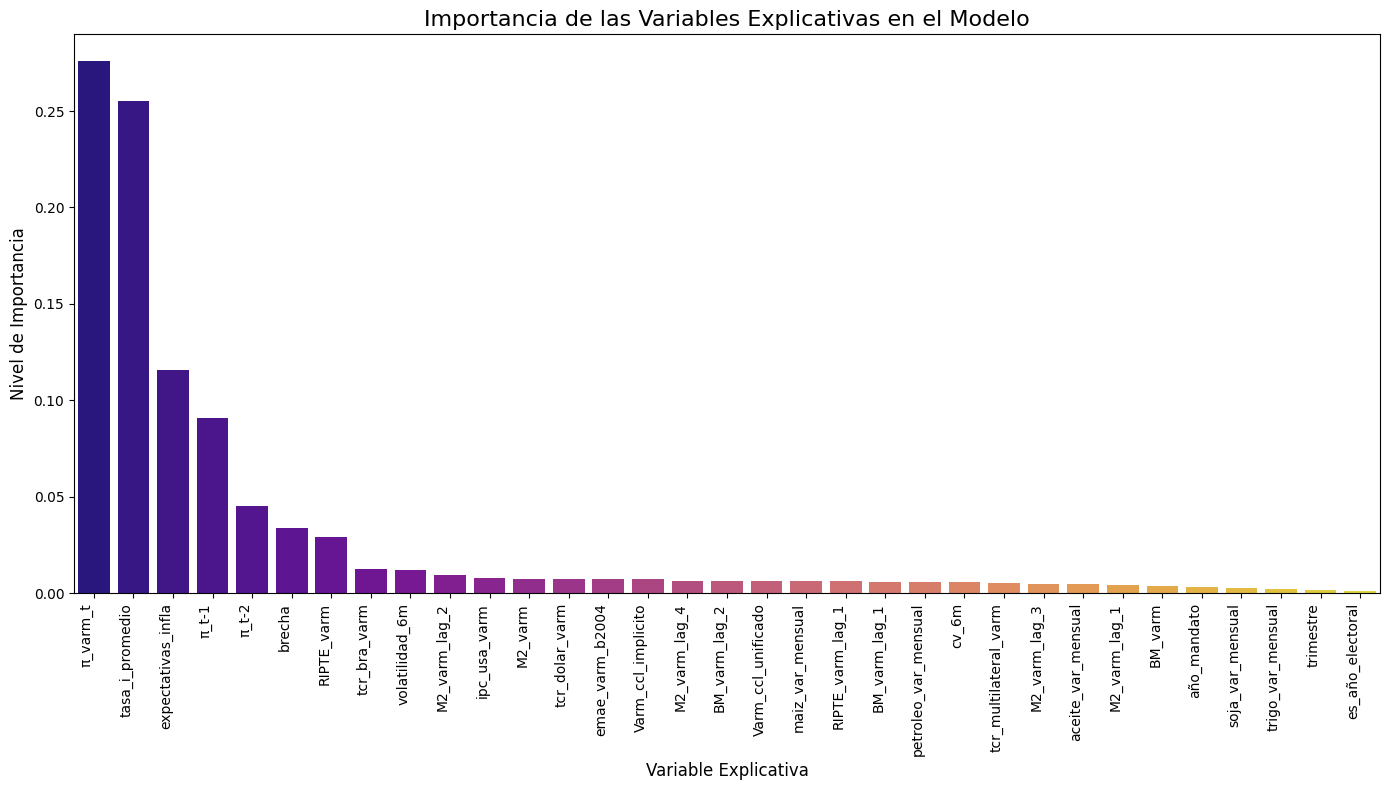

In [ ]:
# Extraemos la importancia de cada feature. Es un array de números.
importances = final_model.feature_importances_

# Necesitamos la lista de nombres de las features que usamos para entrenar
# (la misma lista que creamos antes)
features

# Creamos un DataFrame para una Manipulación Fácil.
# El mismo une los nombres de las features con sus scores de importancia
df_importancias = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Ordenamos el DataFrame de mayor a menor importancia para que el gráfico sea más legible
df_importancias_sorted = df_importancias.sort_values(by='Importance', ascending=False)

# Ahora, lo divertido... graficar

plt.figure(figsize=(14, 8)) # Ajustamos el tamaño para un gráfico vertical
# Usamos un gráfico de barras vertical de seaborn
sns.barplot(
    x='Feature',  # Ahora Feature en el eje x
    y='Importance', # Y Importance en el eje y
    data=df_importancias_sorted,
    palette='plasma', # Una paleta de colores agradable
    hue='Feature', # Añadimos hue='Feature' como sugiere la advertencia
    legend=False # Desactivamos la leyenda ya que hue es la misma variable que x
)

plt.title('Importancia de las Variables Explicativas en el Modelo', fontsize=16)
plt.xlabel('Variable Explicativa', fontsize=12) # Etiquetas ajustadas
plt.ylabel('Nivel de Importancia', fontsize=12) # Etiquetas ajustadas
plt.xticks(rotation=90, ha='right') # Rotamos las etiquetas del eje x para que no se solapen
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para que encajen en el área de la figura.
plt.show()

# También puedes imprimir la tabla si quieres ver los valores exactos
#print("\n--- Tabla de Importancia de Variables (de mayor a menor) ---")
#print(df_importancias_sorted)

In [ ]:
# Filtrar el DataFrame para obtener las top 10 variables
df_top_10_importances = df_importancias_sorted.head(10).copy()
df_top_10_importances.reset_index(drop=True, inplace=True)
# Mostrar el nuevo DataFrame
print("\n--- Top 10 Variables Importantes ---")
df_top_10_importances


--- Top 10 Variables Importantes ---


,Feature,Importance
0,π_varm_t,0.275969
1,tasa_i_promedio,0.255126
2,expectativas_infla,0.115805
3,π_t-1,0.090603
4,π_t-2,0.045212
5,brecha,0.033656
6,RIPTE_varm,0.029191
7,tcr_bra_varm,0.012336
8,volatilidad_6m,0.011878
9,M2_varm_lag_2,0.009694


#### **Hallazgos:**

El hallazgo al que arrivamos es interesante, puesto que, primero no se verifica lo que la teoria mas ortodoxa sobre la inflación nos indica, "la inflación es un fenomeno monetario" (o por lo menos significativamente, fijarse que el unico agregado monetario que aparece es M2_varm_lag_2). Sin embargo, sí podemos ver que la inflación es un fenomeno nominal, pues la gran mayoría de las variables (top 3) que contribuyen a su epxlicación son variables no reales, exceptuando el tcr_bra (El cuál es muy llamativo).

Algo interesante a destacar el el rol de la tasa de interes, tiene demasiado sentido su posición en el top 3, puesto que por paridad de fisher:
\
$$ i = r + \pi $$
donde:
- \\( i \\) = tasa de interés nominal  
- \\( r \\) = tasa de interés real  
- \\( \pi \\) = tasa de inflación

Si suponemos que la tasa r es constante, dicha ecuación tiene una implicancia directa sobre la tasa de inflación.   

Algo interesante a notar es el papel de las expectativas, estas tienen un rol relativamente importante. Lo cual nos da un indicio de que nuestro modelo podría estar capturando el contexto de alta inflación que veniamos experimentando (ver Cagan Et.al.). Por ultimo y para complementar con lo del contexto de alta inflación, tenemos a los rezagos de la misma, la cual tienen una contribucion relevante i.e. nuestro modelo estaría capturando la inercia inflacionaria.

La variable brecha es soprendente en este top, ya que hay quienes sostienen que la inflación es un fenomeno cambiario. Su importancia relativa podría darnos un indicio de esta relación subyacente.

***Nota***: Esto es solo una posible interpretación de los resultados arrojados. Para nada se pretende probar causalidad, ni corroborar alguna teoria. Nuestro objetivo es netamente predictivo.


### Paso 3: Gráfica del ajuste del modelo

Para visualizar el comportamiento del modelo, se generó un gráfico que compara los valores reales con las predicciones del modelo final sobre el mismo conjunto de datos de entrenamiento (ajuste in-sample). Cabe destacar que esta visualización sirve para ilustrar la capacidad de ajuste del modelo a los datos históricos, pero la métrica de rendimiento más representativa de su poder predictivo es la obtenida a través de la validación cruzada, ya que esta sí se realiza sobre datos no vistos en cada pliegue (fold).

Generando el gráfico...


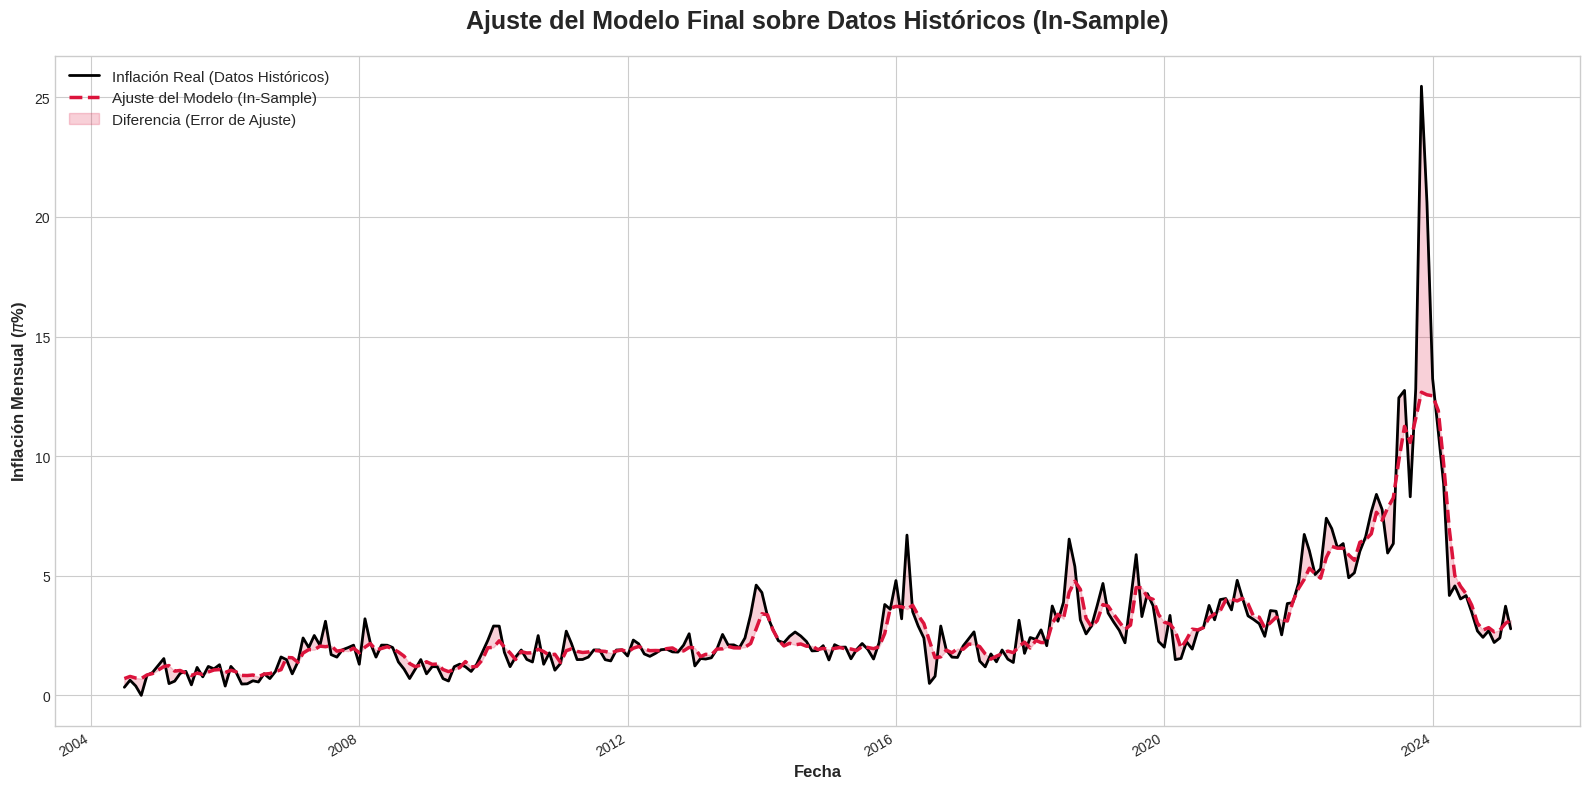

In [ ]:
# Procesos preliminares
y_pred_insample = final_model.predict(X)

y_index_datetime = y.index.to_timestamp()

# Paso siguiente: Crear el gráfico
print("Generando el gráfico...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 8))

# Graficar la línea de la Inflación Real
ax.plot(y_index_datetime, y, color='black', linestyle='-',
        linewidth=2, markersize=5, label='Inflación Real (Datos Históricos)')

# Graficar la línea de las predicciones del modelo sobre esos mismos datos
ax.plot(y_index_datetime, y_pred_insample, color='crimson', linestyle='--',
        linewidth=2.5, label='Ajuste del Modelo (In-Sample)')

# Sombrear el área de error para ver la magnitud de la desviación
ax.fill_between(y_index_datetime, y, y_pred_insample,
                color='crimson', alpha=0.2, label='Diferencia (Error de Ajuste)')

# Configurar Títulos y Etiquetas para máxima claridad
ax.set_title('Ajuste del Modelo Final sobre Datos Históricos (In-Sample)',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax.set_ylabel(r'Inflación Mensual ($\pi$%)', fontsize=12, fontweight='bold')

# Añadir leyenda, formatear eje X y mostrar
ax.legend(loc='best', fontsize=11)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**De la observación del gráfico se desprenden los siguientes puntos:**

**Seguimiento de la Tendencia General:** A simple vista, se puede apreciar que la línea de predicciones del modelo (línea discontinua) sigue de cerca la tendencia general de la serie de inflación real (línea sólida). Esto indica que el modelo ha sido exitoso en capturar la dinámica fundamental y la inercia del proceso inflacionario a lo largo del período analizado.

**Identificación de Períodos de Mayor Error:** El área sombreada, que representa la magnitud del error, nos permite identificar visualmente los momentos de mayor desviación. Se observa que los errores tienden a ser más pronunciados durante los picos de alta volatilidad e.g. la antesala de la hipero que se logra evitar en 2024. Esto es esperable, ya que los modelos estadísticos suelen tener más dificultades para predecir con exactitud durante períodos de alta incertidumbre o shocks abruptos.

**Suavización de los Picos:** El modelo tiende a "suavizar" los picos más extremos de la serie real. Esto es una consecuencia directa de su naturaleza regularizada (con max_depth y min_samples_leaf controlados) y del criterio de optimización (absolute_error), que lo hacen robusto pero menos propenso a realizar predicciones extremas.

`Nota`: Es fundamental subrayar que este gráfico representa el ajuste del modelo a datos conocidos y no su rendimiento predictivo sobre datos futuros. Como tal, ofrece una visión optimista de su performance. Sin embargo, es una herramienta de diagnóstico valiosa que confirma la capacidad del modelo para aprender la estructura de la serie, a la vez que resalta su comportamiento predeciblemente más conservador frente a los episodios de mayor volatilidad. La verdadera medida de su poder predictivo reside en el Error Absoluto Medio (MAE) de 1.0017, obtenido durante la validación cruzada.

### Paso 4: Pronostico

In [ ]:
# Seleccionamos la ultima fila de nuesto dataset original (df)
ultima_fila_datos = df.iloc[-1:]
# A modo de reasegurarnos que todos las columnas sean los feactures definidos
datos_para_predecir = ultima_fila_datos[features]
datos_para_predecir

,π_varm_t,expectativas_infla,π_t-1,π_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,M2_varm_lag_1,...,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre
fecha,,,,,,,,,,,,,,,,,,,,,
2025-04,2.780836,2.3,3.729335,2.401627,32.417895,7.089766,0.832219,0.117597,4.056237,3.419029,...,0.023615,0.117555,-0.026668,-0.067889,0.037629,0.541937,0.200057,2,False,2


In [ ]:
# --- PASO 2: Seleccionar el Modelo Final y Predecir ---

# Seleccionamos nuestro mejor modelo, el campeón del GridSearchCV
modelo_para_el_futuro = final_model
# Alternativa: modelo_para_el_futuro = modelo_final_manual

# Usamos el método .predict() sobre nuestros datos de Abril
prediccion_array = modelo_para_el_futuro.predict(datos_para_predecir)

# El resultado es un array de numpy con un solo elemento. Lo extraemos.
prediccion_final_mayo_2025 = prediccion_array[0]


# --- PASO 3: Mostrar el Resultado ---
print("\n--- 📣 RESULTADO FINAL 📣 ---")
print(f"La predicción de inflación para Mayo de 2025 es: {prediccion_final_mayo_2025:.2f}%")


--- 📣 RESULTADO FINAL 📣 ---
La predicción de inflación para Mayo de 2025 es: 2.95%


#### ¿Es una buena predicción?

Dado que por cuestiones de tiempo y disponibilidad de datos bajo el desarrollo de este modelo nos quedamos con datos hasta Marzo-2025. El objetivo fue que con los datos de Abril podamos predecir la inflación de Mayo.

Puesto que ya se conoce el dato de inflación de Mayo a estas alturas del mes **(1.5%)**, podemos evaluar qué tan bien fue la predicción de nuestro modelo para dicha fecha.

Consideramos que una diferencia de 1.45 puntos porcentuales es un poco desalentante. Estamos por encima del del MAE promedio de la validación cruzada. Sin embargo, no está en un orden de magnitud completamente diferente. No predijo 10% ni -2%. Está en lo que podríamos llamar un "rango de error plausible", aunque en el extremo superior.

Consideramos que el mes que podría estar afectando nuestra proyeccion es el mes de Marzo, ya que fue un mes donde hubo mucha volatilidad, sobre todo con respecto a las expectativas (la cual, consecuentemente afecta a todas las demas variables). Recordemos que el mes siguiente, corrian rumores de que se sacaba el cepo (que efectivamente luego se quita el 14 de Abril), el cual tambien representa un punto de quiebre estructural que nuestro modelo podría no estar captando.

Recordemos la conclusión sobre la "personalidad" de nuestro modelo a la que habiamos arrivado anteriormente.
El mismo está diseñado para no reaccionar de forma exagerada en las señales de un solo mes, es un modelo "prudente".

`Conclusión`: Este es un hallazgo clave puesto que nos da un punto de partida para reconsiderar variables e hiperparametros. Ademas, consideramos que mientras mas "normal" sea el contexto economico Argentino, mas probabilidad hay de que nuestro modelo sea mas atinado.



### Conclusión general del modelo

Finalmente llegamos a conclusiones y hallazgos interesantes, debido a cuestiones de tiempo e inputs para realizar el trabajo, este proyecto, que a primeras vistas parece ser ambicioso, como se menciono en el desarrollo del modelo de now-casting, sienta las bases para seguir profundizandolo mas a fondo en periodos posteriores.

Queda mucho por hacer aun, pero estos resultados obtenidos dejan en claro que el proceso inflacionario y, sobre todo, el pais Argentina, es complicado. Tiene ciclos muy abruptos y marcados, y aqui ya no nos referimos solo al proceso economico, sino a todo el espectro que un pais puede tener, desde ciclos politicos hasta ciclos culturales.



# Fuente de la base de datos

1. **Precios Internacionales de Commodities**
SOJA, MAÍZ, TRIGO, PETRÓLEO
Fuente: IMF – Primary Commodity Price System (Mensual)
Enlace: https://www.imf.org/en/Data

- **Índice de precios internacionales de commodities relevantes para Argentina**
Fuente: Banco Central de la República Argentina (BCRA)
Comentario: Disponible desde 2001.

2. **Tipo de Cambio**
Tipo de Cambio Multilateral (ITCRM)
Fuente: BCRA – Índices de Tipo de Cambio Multilateral
Enlace: https://www.bcra.gob.ar/PublicacionesEstadisticas/Tipo_de_cambio_multilateral.asp

3. **Inflación Argentina**
Precios Minoristas – Serie Histórica (GBA y fuentes alternativas)
Fuente: Centro de Estudios Sociales y Financieros (CES) – Bolsa de Comercio de Santa Fe
Enlace: https://www.bcsf.com.ar/ces/base-datos/tabla/55/precios-minoristas-serie-historica-gba-y-fuentes-alternativas

- **Índice de Precios al Consumidor Nacional** (IPC base dic-2016)
Fuente: INDEC / Secretaría de Política Económica (SSPM)
Enlace: https://www.datos.gob.ar/dataset/sspm-indice-precios-al-consumidor-nacional-ipc-base-diciembre-2016/archivo/sspm_145.3

4. **Inflación Internacional**
Inflación Estados Unidos (CPI – All Urban Consumers)
Fuente: FRED – Federal Reserve Bank of St. Louis
Enlace: https://fred.stlouisfed.org/series/CPIAUCSL

5. **Salarios**
RIPTE (Remuneración Imponible Promedio de los Trabajadores Estables)
Fuente: SSPM – Secretaría de Seguridad Social
Enlace: https://datos.gob.ar/dataset/sspm-remuneracion-imponible-promedio-trabajadores-estables-ripte

6. **Agregados Monetarios y Datos Financieros**
Principales Variables del BCRA
Fuente: BCRA
Enlace: https://www.bcra.gob.ar/PublicacionesEstadisticas/Principales_variables.asp junto con https://www.datos.gob.ar/series/api/series/?ids=90.1_AMTM2_0_0_31

7. Dólar CCL (Contado con Liquidación)
Datos históricos de CCL (Galicia, entre otros)
Fuentes:
- https://es.investing.com/equities/gp-fin-galicia-historical-data
- https://www.rava.com/perfil/DOLAR%20CCL

8. Actividad Económica
EMAE – Estimador Mensual de Actividad Económica
Fuente: Datos.gob.ar
Enlace: https://datos.gob.ar/series/api/series/?ids=143.3_NO_PR_2004_A_31

- ISD – Indicadores Sectoriales Diversos
Fuente: Datos.gob.ar
Enlace: https://datos.gob.ar/series/api/series/?ids=10.3_ISD_1993_M_31

